In [1]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.modeling import models, fitting

from dust_extinction.averages import CT06_MWGC 

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map
from smart_plotters import cmd_plot 

from mpl_plot_templates import adaptive_param_plot


        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/analysis/plot_tools.py:625: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/analysis/plot_tools.py:625: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).to(u.marcsec).value:0.1f}', fontsize=10)
/blue/adamginsburg/adamginsburg/jwst/brick-jwst-2221/brick2221/analysis/plot_tools.py:631: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title(f'{filtername} $\mu$={np.median(sep).to(u.marcsec).value:0.1f} $\sigma$={np.std(sep).

In [2]:
print('test')

test


In [3]:
def get_rc_sel_mask(cat):
    x = np.linspace(0, 2.5, 10)
    
    x0 = 0.52
    mask_x0_left = cat.color('f182m', 'f212n') > x0

    y0 = 14.8
    mask_above_y0 = cat.band('f182m') > y0
    mask_rc = mask_above_y0 & mask_x0_left

    pt1 = (0.5, 14.3)
    pt2 = (2.0, 20.)
    y1 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_below_y1 = cat.band('f182m') > ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_below_y1 & mask_rc

    pt1 = (0.5, 15.5)
    pt2 = (2.0, 20.9)
    y2 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_above_y2 = cat.band('f182m') < ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_rc & mask_above_y2

    return mask_rc

# Cloud C

In [4]:
cat_use = make_cat_use()
cat_use.catalog['Av'] = cat_use.get_Av('f182m', 'f212n')
cat_use.catalog['N(CO)'] = co_map.get_co_ice_column(cat_use, cat_use.catalog['Av'], ext=CT06_MWGC(), ref_band='f405n')

In [5]:
cat_rc = JWSTCatalog(cat_use.catalog[get_rc_sel_mask(cat_use)])

In [6]:
fn = '/orange/adamginsburg/jwst/cloudc/images/jw02221-o002_t001_nircam_clear-f405n-merged_i2d.fits'
hdu = fits.open(fn)
ww = WCS(hdu['SCI'].header)
nanfield = np.nan * hdu['SCI'].data

In [7]:
reg_f = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_short.region')
reg_b = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudb.region')
reg_c1 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc1_ice.reg')
reg_c2 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudc2_ice.reg')
reg_d = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/cloudd_ice.reg')
reg_fil_r = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/filament_right.region')
reg_left_cd = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/left_cloudd.region')
reg_c_n = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_north.region')
reg_c_s = Regions.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/regions_/cloudc_south.region')

In [8]:
cat_f = JWSTCatalog(cat_use.table_region_mask(reg_f, ww))
cat_c1 = JWSTCatalog(cat_use.table_region_mask(reg_c1, ww))
cat_c2 = JWSTCatalog(cat_use.table_region_mask(reg_c2, ww))
cat_c = JWSTCatalog(cat_use.table_region_mask([reg_c1[0], reg_c2[0]], ww))
cat_d = JWSTCatalog(cat_use.table_region_mask(reg_d, ww))
cat_b = JWSTCatalog(cat_use.table_region_mask(reg_b, ww))
cat_fil_r = JWSTCatalog(cat_use.table_region_mask(reg_fil_r, ww))
cat_left_cd = JWSTCatalog(cat_use.table_region_mask(reg_left_cd, ww))
cat_c_n = JWSTCatalog(cat_use.table_region_mask(reg_c_n, ww))
cat_c_s = JWSTCatalog(cat_use.table_region_mask(reg_c_s, ww))

(22.0, 14.5)

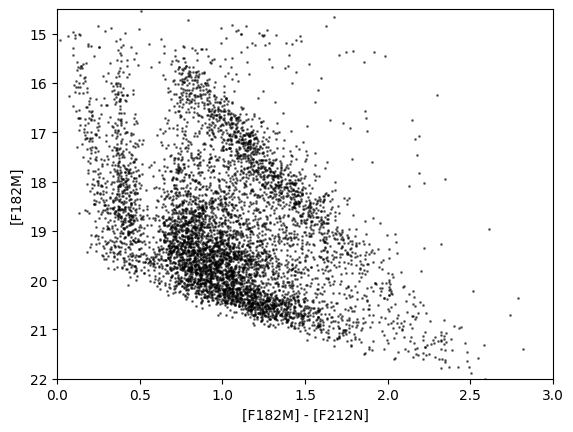

In [9]:
cat_f.plot_CMD('f182m', 'f212n', 'f182m', color='k', s=1, alpha=0.5)
plt.xlim(0, 3)
plt.ylim(22, 14.5)

In [10]:
mask_dustridge = np.logical_or(cat_rc.get_region_mask(reg_d, ww), cat_rc.get_region_mask(reg_c1, ww))
mask_dustridge = np.logical_or(mask_dustridge, cat_rc.get_region_mask(reg_c2, ww))
cat_dustridge_rc = JWSTCatalog(cat_rc.catalog[mask_dustridge])

In [11]:
cat_f_rc = JWSTCatalog(cat_rc.table_region_mask(reg_f, ww))
cat_c1_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c1, ww))
cat_c2_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c2, ww))
cat_c_rc = JWSTCatalog(cat_rc.table_region_mask([reg_c1[0], reg_c2[0]], ww))
cat_d_rc = JWSTCatalog(cat_rc.table_region_mask(reg_d, ww))
cat_b_rc = JWSTCatalog(cat_rc.table_region_mask(reg_b, ww))
cat_fil_r_rc = JWSTCatalog(cat_rc.table_region_mask(reg_fil_r, ww))
cat_left_cd_rc = JWSTCatalog(cat_rc.table_region_mask(reg_left_cd, ww))
cat_c_n_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c_n, ww))
cat_c_s_rc = JWSTCatalog(cat_rc.table_region_mask(reg_c_s, ww))

# Brick

In [12]:
cat_brick = make_brick_cat()
cat_brick.catalog['Av'] = cat_brick.get_Av('f182m', 'f212n')
cat_brick.catalog['N(CO)'] = co_map.get_co_ice_column(cat_brick, cat_brick.catalog['Av'], ext=CT06_MWGC(), ref_band='f405n')

Reading /orange/adamginsburg/jwst/brick/catalogs/basic_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits


In [13]:
cat_brick_rc = JWSTCatalog(cat_brick.catalog[get_rc_sel_mask(cat_brick)])

In [14]:
reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')


In [15]:
fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
hdu_brick = fits.open(fn_brick)
ww_brick = WCS(hdu_brick['SCI'].header)
nanfield_brick = np.nan * hdu_brick['SCI'].data

In [16]:
cat_brick_north = JWSTCatalog(cat_brick.table_region_mask(reg_brick_north, ww_brick)) #  
cat_brick_south = JWSTCatalog(cat_brick.table_region_mask(reg_brick_south, ww_brick))
cat_brick_head = JWSTCatalog(cat_brick.table_region_mask(reg_brick_head, ww_brick))
cat_brick_sfluff = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfluff, ww_brick))
cat_brick_nfluff = JWSTCatalog(cat_brick.table_region_mask(reg_brick_nfluff, ww_brick))
cat_brick_sfr = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfr, ww_brick))
cat_brick_punch = JWSTCatalog(cat_brick.table_region_mask(reg_brick_punch, ww_brick))
cat_brick_sfore = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfore, ww_brick))
cat_brick_nclear = JWSTCatalog(cat_brick.table_region_mask(reg_brick_nclear, ww_brick))
cat_brick_topc = JWSTCatalog(cat_brick.table_region_mask(reg_brick_topc, ww_brick))
cat_brick_sfrwide = JWSTCatalog(cat_brick.table_region_mask(reg_brick_sfrwide, ww_brick))

In [17]:
cat_brick_north_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_north, ww_brick)) #  
cat_brick_south_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_south, ww_brick))
cat_brick_head_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_head, ww_brick))
cat_brick_sfluff_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfluff, ww_brick))
cat_brick_nfluff_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_nfluff, ww_brick))
cat_brick_sfr_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfr, ww_brick))
cat_brick_punch_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_punch, ww_brick))
cat_brick_sfore_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfore, ww_brick))
cat_brick_nclear_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_nclear, ww_brick))
cat_brick_topc_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_topc, ww_brick))
cat_brick_sfrwide_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_sfrwide, ww_brick))

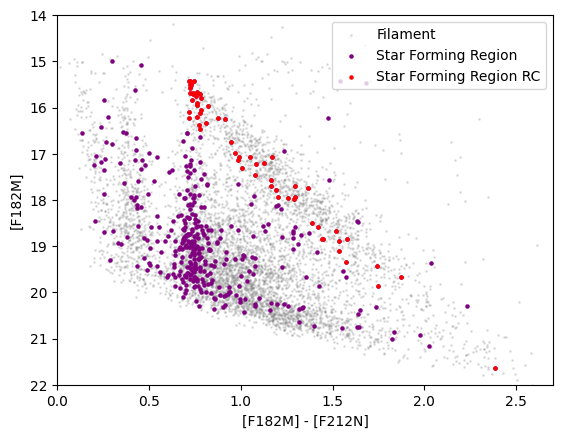

In [18]:
ax = plt.subplot(111)

cat_f.plot_CMD('f182m', 'f212n', 'f182m', color='grey', s=1, label='Filament', ax=ax, alpha=0.2)
cat_brick_sfr.plot_CMD('f182m', 'f212n', 'f182m', color='purple', s=5, label='Star Forming Region', ax=ax)
cat_brick_sfr_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', s=5, label='Star Forming Region RC', ax=ax)
ax.set_xlim(0, 2.7)
ax.set_ylim(22, 14)
ax.legend(loc='upper right')

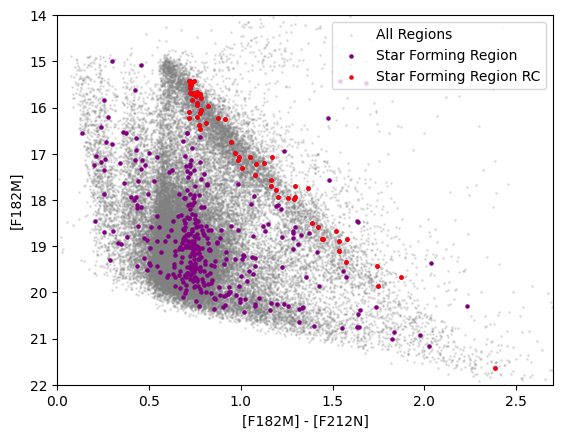

In [19]:
ax = plt.subplot(111)

cat_brick.plot_CMD('f182m', 'f212n', 'f182m', color='grey', s=1, label='All Regions', ax=ax, alpha=0.2)
cat_brick_sfr.plot_CMD('f182m', 'f212n', 'f182m', color='purple', s=5, label='Star Forming Region', ax=ax)
cat_brick_sfr_rc.plot_CMD('f182m', 'f212n', 'f182m', color='red', s=5, label='Star Forming Region RC', ax=ax)
ax.set_xlim(0, 2.7)
ax.set_ylim(22, 14)
ax.legend(loc='upper right')

In [20]:
np.nansum(cat_brick.color('f182m', 'f212n') < 0.5)

np.int64(3595)

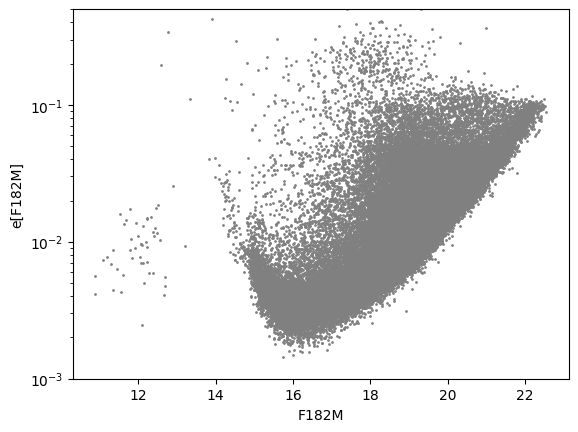

In [21]:
plt.scatter(cat_use.band('f182m'), cat_use.emag('f182m'), s=1, color='grey')
plt.xlabel('F182M')
plt.ylabel('e[F182M]')
plt.ylim(0.001, 0.5)
plt.yscale('log')

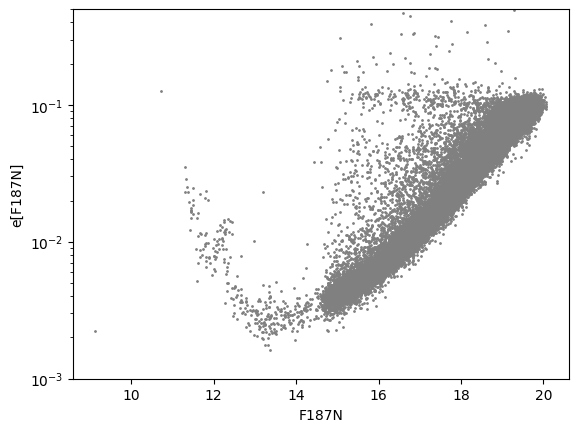

In [22]:
plt.scatter(cat_use.band('f187n'), cat_use.emag('f187n'), s=1, color='grey')
plt.xlabel('F187N')
plt.ylabel('e[F187N]')
plt.ylim(0.001, 0.5)
plt.yscale('log')

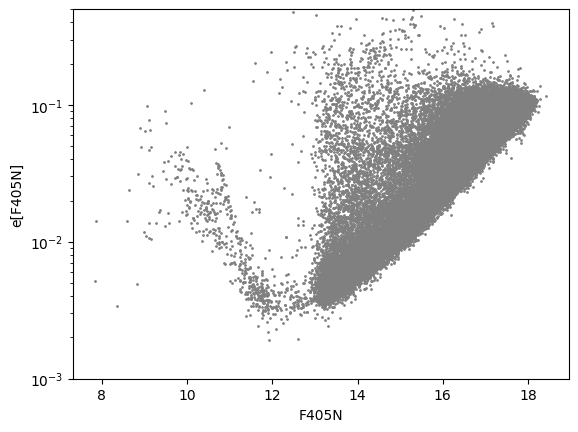

In [23]:
plt.scatter(cat_use.band('f405n'), cat_use.emag('f405n'), s=1, color='grey')
plt.xlabel('F405N')
plt.ylabel('e[F405N]')
plt.ylim(0.001, 0.5)
plt.yscale('log')

# Stellar Density

In [24]:
from astropy.wcs.utils import proj_plane_pixel_scales


def get_angular_area(reg, ww):
    pix_scales = proj_plane_pixel_scales(ww) * u.deg / u.pix
    pix_area = (reg[0].to_pixel(ww).area*u.pix**2) # convert to arcsec^2 then parsec^2
    pixel_to_angle = pix_scales[0] * pix_scales[1] # deg^2 / pix^2
    angle_area = pix_area * pixel_to_angle # area in degrees
    
    return angle_area.to(u.arcsec**2)

def get_physical_area(reg, ww, distance=8100*u.pc):
    angle_area = get_angular_area(reg, ww)
    parsec_area = angle_area.to(u.rad**2) * (8100*u.pc)**2 / u.rad**2

    return parsec_area

def find_foreground_stellar_density(cat, reg, ww):
    ang_area = get_angular_area(reg, ww)
    cat_fore = cat.catalog[cat.color('f182m', 'f212n') < 0.55]
    num_fore = len(cat_fore)
    density = num_fore / ang_area
    return density

def find_stellar_density(cat, reg, ww):
    ang_area = get_angular_area(reg, ww)
    num = len(cat)
    density = num / ang_area
    return density

In [25]:
find_foreground_stellar_density(cat_f, reg_f, ww)*(get_angular_area(reg_f, ww)).to(u.arcsec**2)

<Quantity 797.>

In [26]:
find_stellar_density(cat_f_rc.catalog, reg_f, ww)*(1*u.arcmin*2*u.arcmin).to(u.arcsec**2)

<Quantity 954.33811888>

In [27]:
find_stellar_density(cat_f.catalog, reg_f, ww)*(1*u.arcmin*2*u.arcmin).to(u.arcsec**2)

<Quantity 8462.85650602>

In [28]:
#reg_mask_f = cat_f.get_region_mask(reg_f, ww)

#JWSTCatalog(cat_rc.table_region_mask(reg_f, ww))
#get_region_mask
#get_rc_sel_mask(cat_use)

# find stars that are in the 
len(cat_f_rc.catalog) / np.sum(cat_f.color('f182m', 'f212n') > 0.55)*797

np.float64(172.34879757621664)

In [29]:
len(cat_f_rc.catalog) / np.sum(cat_f.color('f182m', 'f212n') > 0.55)

np.float64(0.21624692293126302)

<Axes: xlabel='[F182M] - [F212N]', ylabel='[F212N]'>

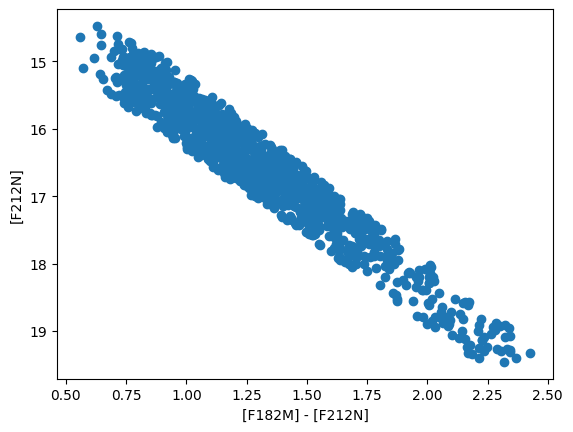

In [30]:
cat_f_rc.plot_CMD('f182m', 'f212n', 'f212n')

(22.0, 14.5)

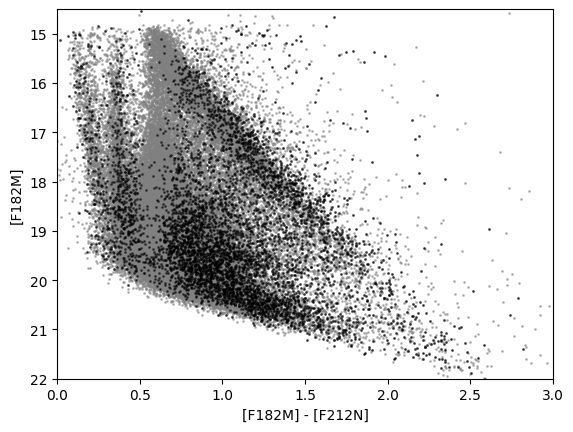

In [31]:
cat_use.plot_CMD('f182m', 'f212n', 'f182m', color='grey', s=1, alpha=0.5)
cat_f.plot_CMD('f182m', 'f212n', 'f182m', color='k', s=1, alpha=0.5)
plt.xlim(0, 3)
plt.ylim(22, 14.5)

(23.0, 14.5)

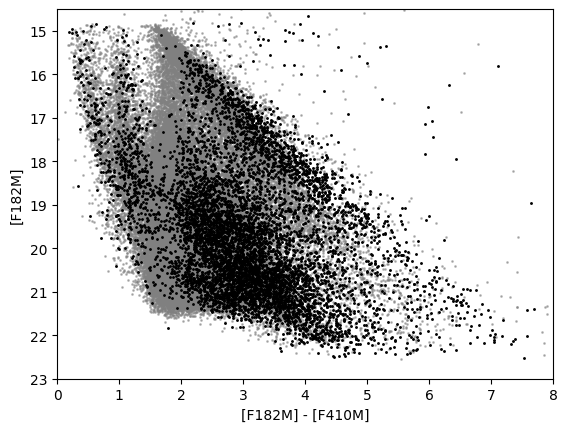

In [32]:
cat_use.plot_CMD('f182m', 'f410m', 'f182m', color='grey', s=1, alpha=0.5)
cat_f.plot_CMD('f182m', 'f410m', 'f182m', color='k', s=1)
plt.xlim(0, 8)
plt.ylim(23, 14.5)

(array([  0.,   0.,   0.,   0.,   0.,   2.,  10.,  67.,  70.,  94., 121.,
        145., 118., 108., 108.,  81.,  59.,  45.,  29.,  17.,  26.,  15.,
         15.,  11.,   1.,   0.,   0.,   0.,   0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9]),
 <BarContainer object of 29 artists>)

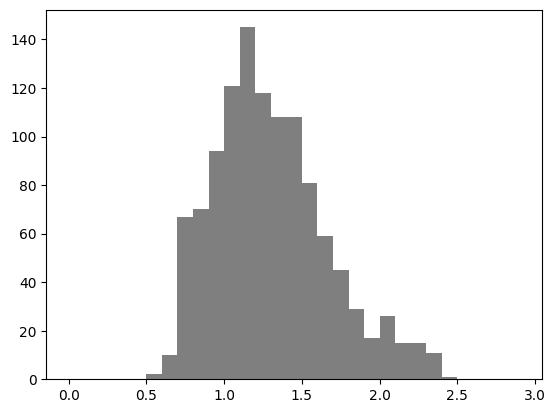

In [33]:
plt.hist(cat_f_rc.color('f182m', 'f212n'), bins=np.arange(0, 3, 0.1), color='k', alpha=0.5)

(array([ 0.,  0.,  0.,  0.,  0.,  6., 84., 47., 19., 32., 58., 44., 61.,
        37., 32., 26., 10., 12.,  9.,  6.,  3.,  8.,  2.,  1.,  1.,  0.,
         0.,  0.,  0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9]),
 <BarContainer object of 29 artists>)

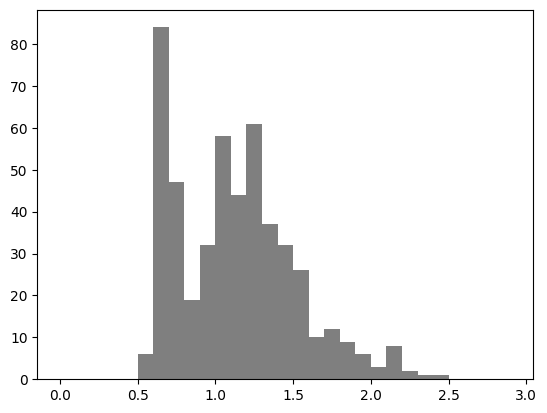

In [34]:
plt.hist(cat_c1_rc.color('f182m', 'f212n'), bins=np.arange(0, 3, 0.1), color='k', alpha=0.5)

(array([ 0.,  0.,  0.,  0.,  0.,  3., 85., 29.,  6., 25., 47., 43., 40.,
        36., 23., 19., 17., 15.,  4.,  7., 11.,  3.,  1.,  1.,  3.,  0.,
         0.,  0.,  0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9]),
 <BarContainer object of 29 artists>)

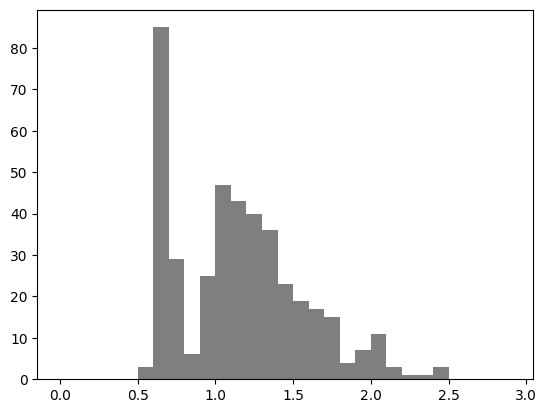

In [35]:
plt.hist(cat_c2_rc.color('f182m', 'f212n'), bins=np.arange(0, 3, 0.1), color='k', alpha=0.5)

(array([  0.,   0.,   0.,   0.,   0.,  71., 199.,  47.,  42.,  45.,  54.,
         65.,  84.,  78.,  86.,  91.,  74.,  48.,  47.,  28.,  22.,  21.,
          9.,  12.,   5.,   1.,   0.,   0.,   0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9]),
 <BarContainer object of 29 artists>)

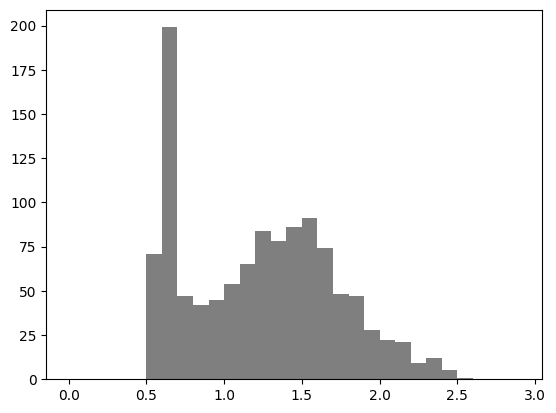

In [36]:
plt.hist(cat_d_rc.color('f182m', 'f212n'), bins=np.arange(0, 3, 0.1), color='k', alpha=0.5)

# Combined Figure

In [37]:
catalogs_rc = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc,
               cat_brick_sfr_rc, cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_topc_rc, cat_brick_sfrwide_rc]
labels = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
          'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff',
          'Brick Star-Forming Region', 'Brick Punch-Out', 'Brick South Foreground', 'Brick North Clear', 'Brick Top Center', 'Brick Star-Forming Wide']

In [38]:
len(catalogs_rc)

20

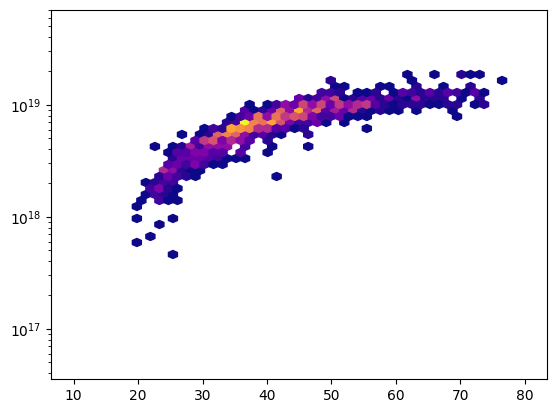

In [39]:
plt.hexbin(cat_f_rc.catalog['Av'], cat_f_rc.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(5e16), np.log10(5e19)), yscale='log')

In [40]:
import matplotlib.lines as mlines


In [41]:
from astropy.table import Table
tab = Table.read('/orange/adamginsburg/jwst/cloudc/lactea-filament/lactea-filament/notebooks/tab_dat.csv', delimiter=' ')#.write('tab_dat.fits', format='fits', overwrite=True)
#  (J2000) (J2000) (10^18 cm^−2) (10^18 cm^−2) (10^18 cm^−2)    (10^22 cm^−2) (mJy)
#tab.units = {'RA': u.deg, 'DEC': u.deg, 'F410M': u.mJy}#, 'N_HI': u.cm**-2, 'N_H2': u.cm**-2, 'N_H_tot': u.cm**-2, 'N_H_tot_err': u.cm**-2, 'flux_187': u.mJy}
tab['F410M'].unit = u.mJy
tab['RA'].unit = u.deg
tab['Dec'].unit = u.deg
tab['NH2'].unit = 10**22 * u.cm**-2
tab['NH2O'].unit = 10**18 * u.cm**-2
tab['NCO2'].unit = 10**18 * u.cm**-2
tab['NCO'].unit = 10**18 * u.cm**-2
tab['Av'] = tab['NH2']*10**22 * u.cm**-2 / (1.1e21 * u.cm**-2)  # Convert to Av using NH2 to Av conversion factor
tab['Av'].unit = u.mag

#tab['NCO']
NCO_ice = np.zeros(len(tab['NCO']))
NCO_perr = np.zeros_like(NCO_ice)
NCO_nerr = np.zeros_like(NCO_ice)
Av_ice = np.array(tab['Av'])

for i in range(len(NCO_ice)):
    NCO_ice[i] = np.float64(np.array(tab['NCO'])[i].split('+')[0])
    NCO_perr[i] = np.float64(np.array(tab['NCO'])[i].split('+')[1].split("−")[0])
    NCO_nerr[i] = np.float64(np.array(tab['NCO'])[i].split('+')[1].split("−")[1])

NCO_ice = NCO_ice * 1e18  # Convert to cm^-2 for consistency with other values
NCO_perr = NCO_perr * 1e18
NCO_nerr = NCO_nerr * 1e18

elias16 = (19, 10**18.3)

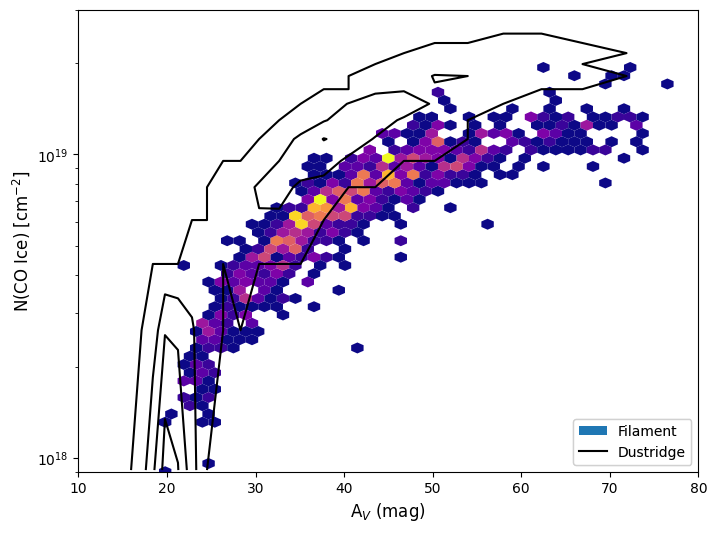

In [42]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

p1 = ax.hexbin(cat_f_rc.catalog['Av'], cat_f_rc.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(9e17), np.log10(3e19)), yscale='log', label='Filament', edgecolors='none')
Av_offset=17
#p5 = plt.errorbar(Av_ice+Av_offset, NCO_ice, yerr=[NCO_nerr, NCO_perr], color='magenta', marker='o', markersize=3, linestyle='none', label='Smith+25', alpha=1)
#p4 = plt.scatter(elias16[0]+Av_offset, elias16[1], color='tab:orange', s=100, marker='x', label='Elias 16')


nbins = 30
nlevels = 3
_ = adaptive_param_plot(np.array(cat_dustridge_rc.catalog['Av']), np.array(cat_dustridge_rc.catalog['N(CO)']), bins=np.array([np.logspace(np.log10(10), np.log10(80), nbins), np.linspace(5e16, 5e19, nbins)]),
                        axis=ax, marker='none', colors='k', levels=nlevels)

k_line = mlines.Line2D([], [], color='k', marker='none',
                        linestyle='-', label='Dustridge')
#
#artists_and_labels_1['Dustridge'] = k_line

#artists_and_labels_1 = {}
#artists_and_labels_1['Smith+25'] = p5
#artists_and_labels_1['Elias 16'] = p4
#artists_and_labels_1['Filament'] = mlines.Line2D([], [], color='indigo', marker='s', linestyle='none', label='Filament')

#ax.legend(handles=list(artists_and_labels_1.values()),
#              labels=list(artists_and_labels_1.keys()), loc='lower right')
leg1 = plt.legend(handles=[p1, k_line], loc='lower right')
plt.gca().add_artist(leg1)


#artists_and_labels = {}
#NCOofAV = 1.1e21 * np.linspace(0.1, 100, 1000) * 1e-4
#NCOofAV_alt1 = 1.1e21 * np.linspace(0.1, 100, 1000) * 5e-4
#NCOofAV_alt2 = 1.1e21 * np.linspace(0.1, 100, 1000) * 2.5e-4
#NCOofAV_alt3 = 1.1e21 * np.linspace(0.1, 100, 1000) * 1.6e-4
#l2, = plt.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV, linewidth=2, 
#        label='100% of CO in ice if \nN(H$_2$)=1.1$\\times10^{21}$ A$_V$ \nand CO/H$_2$=10$^{-4}$', color='r', linestyle='-.')
#l3, = plt.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt1, linewidth=2, 
#        label='CO/H$_2$=5x10$^{-4}$', color='r', linestyle='--')
#l4, = plt.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt2, linewidth=2, 
#        label='CO/H$_2$=2.5x10$^{-4}$', color='r', linestyle=':')
#l5, = plt.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt3, linewidth=2, 
#        label='CO/H$_2$=1.6x10$^{-4}$', color='r', linestyle='-')
#leg2 = plt.legend(handles=[l2, l5, l4, l3], loc='upper left')

ax.set_xlabel('A$_V$ (mag)', fontsize=12)
ax.set_ylabel('N(CO Ice) [cm$^{-2}$]', fontsize=12)

#ax.legend(handles=list(artists_and_labels.values()),
#              labels=list(artists_and_labels.keys()), loc='lower right')

ax.set_xlim(10, 80)
ax.set_ylim(9e17, 3e19)
ax.set_yscale('log')

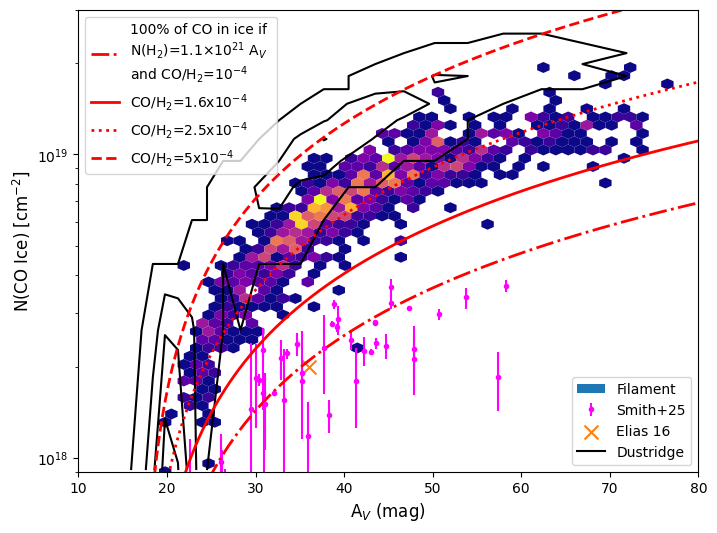

In [43]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

p1 = ax.hexbin(cat_f_rc.catalog['Av'], cat_f_rc.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(9e17), np.log10(3e19)), yscale='log', label='Filament', edgecolors='none')
Av_offset=17
p5 = plt.errorbar(Av_ice+Av_offset, NCO_ice, yerr=[NCO_nerr, NCO_perr], color='magenta', marker='o', markersize=3, linestyle='none', label='Smith+25', alpha=1)
p4 = plt.scatter(elias16[0]+Av_offset, elias16[1], color='tab:orange', s=100, marker='x', label='Elias 16')


nbins = 30
nlevels = 3
_ = adaptive_param_plot(np.array(cat_dustridge_rc.catalog['Av']), np.array(cat_dustridge_rc.catalog['N(CO)']), bins=np.array([np.logspace(np.log10(10), np.log10(80), nbins), np.linspace(5e16, 5e19, nbins)]),
                        axis=ax, marker='none', colors='k', levels=nlevels)

k_line = mlines.Line2D([], [], color='k', marker='none',
                        linestyle='-', label='Dustridge')

artists_and_labels_1 = {}
artists_and_labels_1['Dustridge'] = k_line

artists_and_labels_1['Smith+25'] = p5
artists_and_labels_1['Elias 16'] = p4
artists_and_labels_1['Filament'] = mlines.Line2D([], [], color='indigo', marker='s', linestyle='none', label='Filament')

#ax.legend(handles=list(artists_and_labels_1.values()),
#              labels=list(artists_and_labels_1.keys()), loc='lower right')
leg1 = plt.legend(handles=[p1, p5, p4, k_line], loc='lower right')
plt.gca().add_artist(leg1)


artists_and_labels = {}
NCOofAV = 1.1e21 * np.linspace(0.1, 100, 1000) * 1e-4
NCOofAV_alt1 = 1.1e21 * np.linspace(0.1, 100, 1000) * 5e-4
NCOofAV_alt2 = 1.1e21 * np.linspace(0.1, 100, 1000) * 2.5e-4
NCOofAV_alt3 = 1.1e21 * np.linspace(0.1, 100, 1000) * 1.6e-4
l2, = plt.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV, linewidth=2, 
        label='100% of CO in ice if \nN(H$_2$)=1.1$\\times10^{21}$ A$_V$ \nand CO/H$_2$=10$^{-4}$', color='r', linestyle='-.')
l3, = plt.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt1, linewidth=2, 
        label='CO/H$_2$=5x10$^{-4}$', color='r', linestyle='--')
l4, = plt.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt2, linewidth=2, 
        label='CO/H$_2$=2.5x10$^{-4}$', color='r', linestyle=':')
l5, = plt.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt3, linewidth=2, 
        label='CO/H$_2$=1.6x10$^{-4}$', color='r', linestyle='-')
leg2 = plt.legend(handles=[l2, l5, l4, l3], loc='upper left')

ax.set_xlabel('A$_V$ (mag)', fontsize=12)
ax.set_ylabel('N(CO Ice) [cm$^{-2}$]', fontsize=12)

#ax.legend(handles=list(artists_and_labels.values()),
#              labels=list(artists_and_labels.keys()), loc='lower right')

ax.set_xlim(10, 80)
ax.set_ylim(9e17, 3e19)
ax.set_yscale('log')

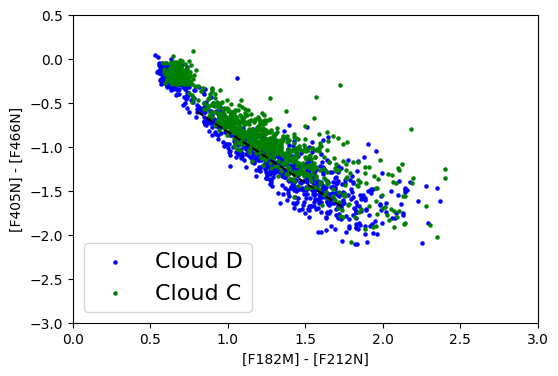

In [44]:
fig = plt.figure(figsize=(6, 4))
#cat_use.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='k', s=1, alpha=0.1)
#cat_dustridge_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='red', s=5, alpha=1, label='Dustridge')
#cat_f_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='indigo', s=5, alpha=1, label='Filament')
cat_d_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='blue', s=5, alpha=1, label='Cloud D')
cat_c1_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='green', s=5, alpha=1, label='Cloud C')
cat_c2_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='green', s=5, alpha=1)#, label='Cloud C2')
plt.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
plt.xlim(0, 3)
plt.ylim(-3, 0.5)
plt.legend(loc='lower left', fontsize=16)

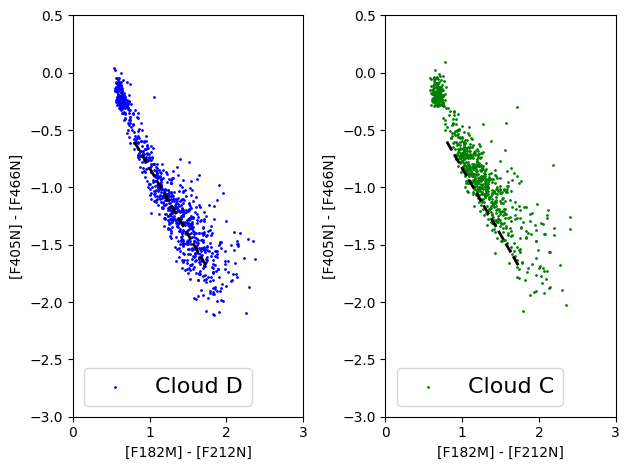

In [45]:
#fig = plt.figure(figsize=(6, 4))
#cat_use.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='k', s=1, alpha=0.1)
#cat_dustridge_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='red', s=5, alpha=1, label='Dustridge')
#cat_f_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='indigo', s=5, alpha=1, label='Filament')
ax1 = plt.subplot(121)
cat_d_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='blue', s=1, alpha=1, label='Cloud D', ax=ax1)
plt.legend(loc='lower left', fontsize=16)
ax2 = plt.subplot(122)
cat_c1_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='green', s=1, alpha=1, label='Cloud C', ax=ax2)
cat_c2_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='green', s=1, alpha=1, ax=ax2)#, label='Cloud C2')

axes = [ax1, ax2]
for ax in axes:
    ax.set_xlim(0, 3)
    ax.set_ylim(-3, 0.5)
    ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed', linewidth=2)
plt.legend(loc='lower left', fontsize=16)
plt.tight_layout()

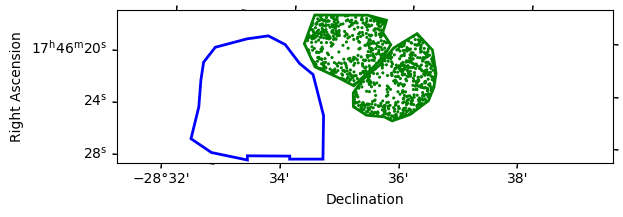

In [46]:
ax = plt.subplot(111, projection=ww)
ax.imshow(nanfield, origin='lower', cmap='gray_r')
#plt.gca().set_aspect('equal')
reg_d[0].to_pixel(ww).plot(ax=ax, edgecolor='blue', facecolor='none', label='Cloud D')
reg_c1[0].to_pixel(ww).plot(ax=ax, edgecolor='green', facecolor='none', label='Cloud C1')
reg_c2[0].to_pixel(ww).plot(ax=ax, edgecolor='green', facecolor='none', label='Cloud C2')
cat_c_rc.plot_position(ax=ax, edgecolor='none', facecolor='green', label='Cloud C RC', transform=ax.get_transform('world'), s=5)
#reg_f[0].to_pixel(ww).plot(ax=ax, edgecolor='indigo', facecolor='none', label='Filament')
plt.xlabel('Declination')
plt.ylabel('Right Ascension')

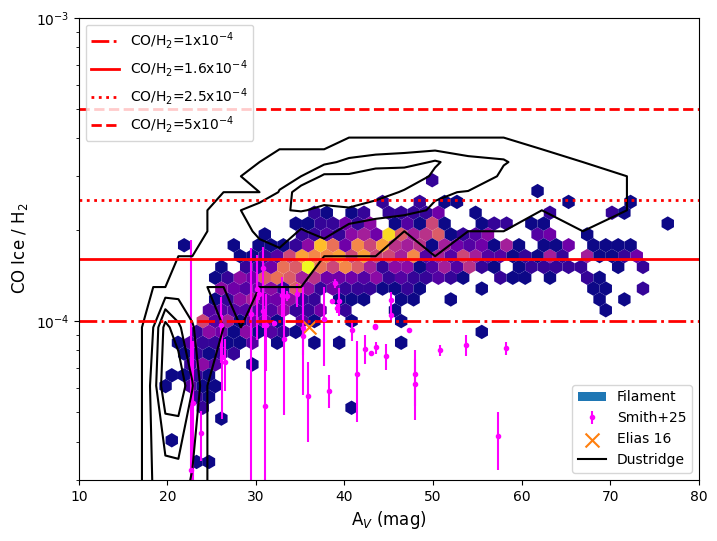

In [47]:
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111)

p1 = ax.hexbin(cat_f_rc.catalog['Av'], cat_f_rc.catalog['N(CO)']/(cat_f_rc.catalog['Av']*1.1e21), gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(1e-5), np.log10(1e-3)), yscale='log', label='Filament', edgecolors='none')
Av_offset=17
p5 = plt.errorbar(Av_ice+Av_offset, NCO_ice/(Av_ice*1.1e21), yerr=[NCO_nerr/(Av_ice*1.1e21), NCO_perr/(Av_ice*1.1e21)], color='magenta', marker='o', markersize=3, linestyle='none', label='Smith+25', alpha=1)
#p5 = plt.scatter(Av_ice+Av_offset, NCO_ice/(Av_ice*1.1e21), color='magenta', marker='o', label='Smith+25', alpha=1)
p4 = plt.scatter(elias16[0]+Av_offset, elias16[1]/(elias16[0]*1.1e21), color='tab:orange', s=100, marker='x', label='Elias 16')


nbins = 30
nlevels = 3
_ = adaptive_param_plot(np.array(cat_dustridge_rc.catalog['Av']), np.array(cat_dustridge_rc.catalog['N(CO)']/(cat_dustridge_rc.catalog['Av']*1.1e21)), bins=np.array([np.logspace(np.log10(10), np.log10(80), nbins), np.linspace(1e-5, 1e-3, nbins)]),
                        axis=ax, marker='none', colors='k', levels=nlevels)

k_line = mlines.Line2D([], [], color='k', marker='none',
                        linestyle='-', label='Dustridge')

artists_and_labels_1['Dustridge'] = k_line

artists_and_labels_1 = {}
artists_and_labels_1['Smith+25'] = p5
artists_and_labels_1['Elias 16'] = p4
artists_and_labels_1['Filament'] = mlines.Line2D([], [], color='indigo', marker='s', linestyle='none', label='Filament')

#ax.legend(handles=list(artists_and_labels_1.values()),
#              labels=list(artists_and_labels_1.keys()), loc='lower right')
leg1 = plt.legend(handles=[p1, p5, p4, k_line], loc='lower right')
plt.gca().add_artist(leg1)


artists_and_labels = {}
l2 = plt.axhline(1e-4, linewidth=2, 
        label='CO/H$_2$=1x10$^{-4}$', color='r', linestyle='-.')
l3 = plt.axhline(1e-4*5, linewidth=2, 
        label='CO/H$_2$=5x10$^{-4}$', color='r', linestyle='--')
l4 = plt.axhline(1e-4*2.5, linewidth=2, 
        label='CO/H$_2$=2.5x10$^{-4}$', color='r', linestyle=':')
l5 = plt.axhline(1e-4*1.6, linewidth=2, 
        label='CO/H$_2$=1.6x10$^{-4}$', color='r', linestyle='-')
leg2 = plt.legend(handles=[l2, l5, l4, l3], loc='upper left')

ax.set_xlabel('A$_V$ (mag)', fontsize=12)
ax.set_ylabel('CO Ice / H$_2$', fontsize=12)

#ax.legend(handles=list(artists_and_labels.values()),
#              labels=list(artists_and_labels.keys()), loc='lower right')

ax.set_xlim(10, 80)
ax.set_ylim(3e-5, 1e-3)
ax.set_yscale('log')

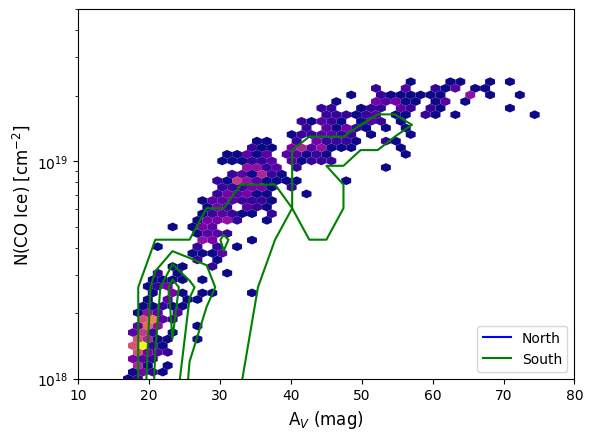

In [48]:
ax = plt.subplot(111)
ax.set_xlim(10, 80)
ax.set_ylim(1e18, 5e19)
ax.set_yscale('log')

#ax.hexbin(cat_f_rc.catalog['Av'], cat_f_rc.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(1e18), np.log10(5e19)), yscale='log', label='Filament', edgecolors='none')
ax.hexbin(cat_brick_north_rc.catalog['Av'], cat_brick_north_rc.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(1e18), np.log10(5e19)), yscale='log', label='North Brick', edgecolors='none')

artists_and_labels = {}

nbins = 30
nlevels = 3
#_ = adaptive_param_plot(np.array(cat_f_rc.catalog['Av']), np.array(cat_f_rc.catalog['N(CO)']), bins=np.array([np.linspace(10, 80, nbins), np.linspace(5e16, 5e19, nbins)]),
#                        axis=ax, marker='none', colors='k', levels=nlevels)
#_ = adaptive_param_plot(np.array(cat_brick_north_rc.catalog['Av']), np.array(cat_brick_north_rc.catalog['N(CO)']), bins=np.array([np.linspace(10, 80, nbins), np.linspace(5e16, 5e19, nbins)]),
#                        axis=ax, marker='none', colors='b', levels=nlevels)
_ = adaptive_param_plot(np.array(cat_brick_south_rc.catalog['Av']), np.array(cat_brick_south_rc.catalog['N(CO)']), bins=np.array([np.linspace(10, 80, nbins), np.linspace(5e16, 5e19, nbins)]),   
                        axis=ax, marker='none', colors='g', levels=nlevels)

#k_line = mlines.Line2D([], [], color='k', marker='none',
#                        linestyle='-', label='Filament')
b_line = mlines.Line2D([], [], color='b', marker='none',
                        linestyle='-', label='North')
g_line = mlines.Line2D([], [], color='g', marker='none',
                        linestyle='-', label='South')

#artists_and_labels['Filament'] = k_line
artists_and_labels['North'] = b_line
artists_and_labels['South'] = g_line

ax.set_xlabel('A$_V$ (mag)', fontsize=12)
ax.set_ylabel('N(CO Ice) [cm$^{-2}$]', fontsize=12)

ax.legend(handles=list(artists_and_labels.values()),
              labels=list(artists_and_labels.keys()), loc='lower right')

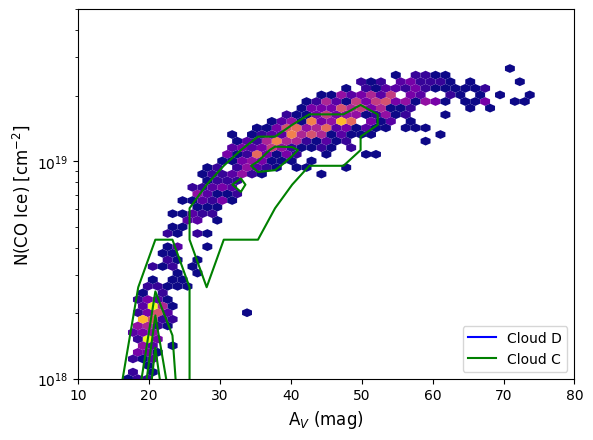

In [49]:
ax = plt.subplot(111)
ax.set_xlim(10, 80)
ax.set_ylim(1e18, 5e19)
ax.set_yscale('log')

#ax.hexbin(cat_f_rc.catalog['Av'], cat_f_rc.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(1e18), np.log10(5e19)), yscale='log', label='Filament', edgecolors='none')
ax.hexbin(cat_d_rc.catalog['Av'], cat_d_rc.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(1e18), np.log10(5e19)), yscale='log', label='Cloud D', edgecolors='none')

artists_and_labels = {}

nbins = 30
nlevels = 3
#_ = adaptive_param_plot(np.array(cat_f_rc.catalog['Av']), np.array(cat_f_rc.catalog['N(CO)']), bins=np.array([np.linspace(10, 80, nbins), np.linspace(5e16, 5e19, nbins)]),
#                        axis=ax, marker='none', colors='k', levels=nlevels)
#_ = adaptive_param_plot(np.array(cat_brick_north_rc.catalog['Av']), np.array(cat_brick_north_rc.catalog['N(CO)']), bins=np.array([np.linspace(10, 80, nbins), np.linspace(5e16, 5e19, nbins)]),
#                        axis=ax, marker='none', colors='b', levels=nlevels)
_ = adaptive_param_plot(np.array(cat_c_rc.catalog['Av']), np.array(cat_c_rc.catalog['N(CO)']), bins=np.array([np.linspace(10, 80, nbins), np.linspace(5e16, 5e19, nbins)]),   
                        axis=ax, marker='none', colors='g', levels=nlevels)

#k_line = mlines.Line2D([], [], color='k', marker='none',
#                        linestyle='-', label='Filament')
b_line = mlines.Line2D([], [], color='b', marker='none',
                        linestyle='-', label='Cloud D')
g_line = mlines.Line2D([], [], color='g', marker='none',
                        linestyle='-', label='Cloud C')

#artists_and_labels['Filament'] = k_line
artists_and_labels['Cloud D'] = b_line
artists_and_labels['Cloud C'] = g_line

ax.set_xlabel('A$_V$ (mag)', fontsize=12)
ax.set_ylabel('N(CO Ice) [cm$^{-2}$]', fontsize=12)

ax.legend(handles=list(artists_and_labels.values()),
              labels=list(artists_and_labels.keys()), loc='lower right')

In [50]:
from mpl_plot_templates import adaptive_param_plot
#mpl_plot_templates.adaptive_param_plot
#adaptive_param_plot??

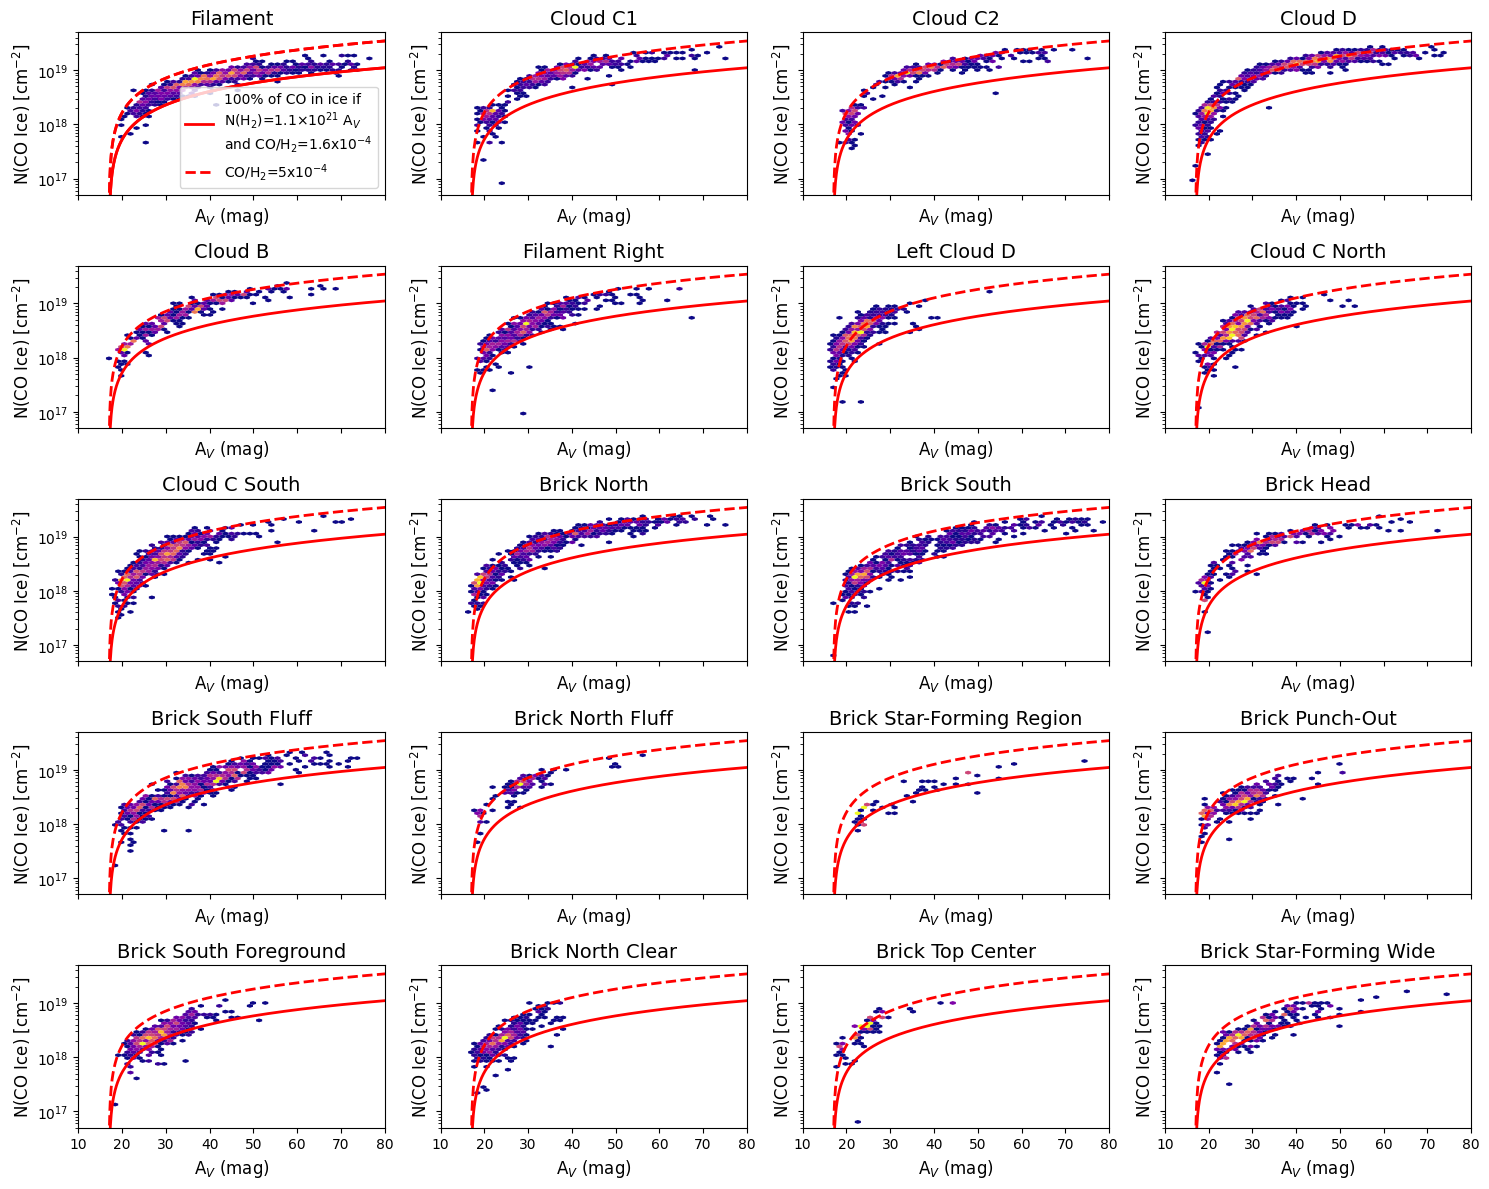

In [51]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharex=True, sharey=True)

catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']

Av_offset = 17
NCOofAV_alt1 = 1.1e21 * np.linspace(0.1, 100, 1000) * 5e-4
NCOofAV_alt3 = 1.1e21 * np.linspace(0.1, 100, 1000) * 1.6e-4

l1, = axes.flatten()[0].plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt3, linewidth=2, 
        label='100% of CO in ice if \nN(H$_2$)=1.1$\\times10^{21}$ A$_V$ \nand CO/H$_2$=1.6x10$^{-4}$', color='r', linestyle='-')
l3, = axes.flatten()[0].plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt1, linewidth=2, 
        label='CO/H$_2$=5x10$^{-4}$', color='r', linestyle='--')
axes.flatten()[0].legend()

for i in range(20):
    cat = catalogs_rc[i]
    ax = axes.flatten()[i]
    ax.hexbin(cat.catalog['Av'], cat.catalog['N(CO)'], gridsize=50, mincnt=1, cmap='plasma', extent=(10, 80, np.log10(5e16), np.log10(5e19)), yscale='log', edgecolors='none')
    ax.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt3, linewidth=2, color='r', linestyle='-')
    ax.plot(np.linspace(0.1, 100, 1000)+Av_offset, NCOofAV_alt1, linewidth=2, color='r', linestyle='--')
    ax.set_xlabel('A$_V$ (mag)', fontsize=12)
    ax.set_ylabel('N(CO Ice) [cm$^{-2}$]', fontsize=12)
    ax.set_xlim(10, 80)
    ax.set_ylim(5e16, 5e19)
    ax.set_yscale('log')
    ax.set_title(labels[i], fontsize=14)

plt.tight_layout()

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_vs_Av.png', dpi=300, bbox_inches='tight')
plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_vs_Av.pdf', bbox_inches='tight')

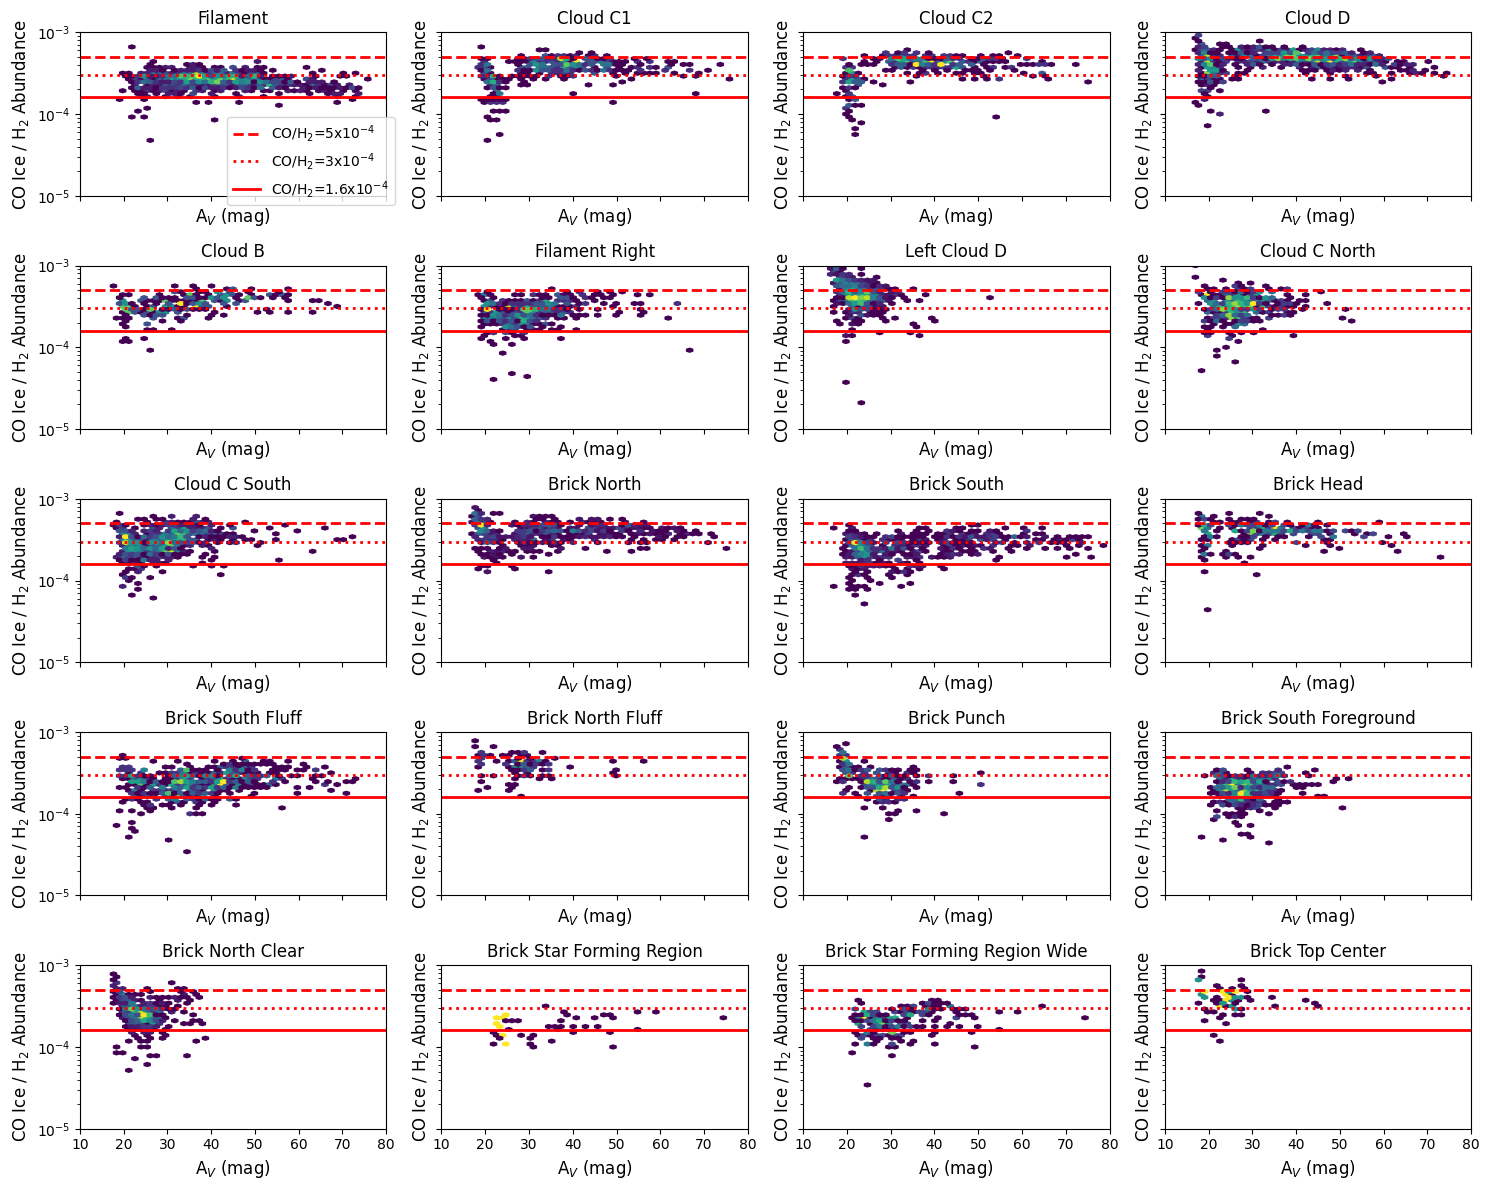

In [54]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharex=True, sharey=True)

catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']

for i in range(20):
    ax = axes.flatten()[i]
    cat = catalog_list[i]
    abundance_calc = cat.catalog['N(CO)']/((cat.catalog['Av']-16)*1.1e21)
    ax.hexbin(cat.catalog['Av'], abundance_calc, yscale='log', extent=(10, 80, np.log10(1e-5), np.log10(1e-3)), cmap='viridis', gridsize=50, mincnt=1)
    ax.set_title(name_list[i])

    ax.axhline(5e-4, linewidth=2, color='r', linestyle='--', label='CO/H$_2$=5x10$^{-4}$')
    ax.axhline(3e-4, linewidth=2, color='r', linestyle=':', label='CO/H$_2$=3x10$^{-4}$')
    ax.axhline(1.6e-4, linewidth=2, color='r', linestyle='-', label='CO/H$_2$=1.6x10$^{-4}$')

    ax.set_xlabel('A$_V$ (mag)', fontsize=12)
    ax.set_ylabel('CO Ice / H$_2$ Abundance', fontsize=12)
    ax.set_yscale('log')
    ax.set_xlim(10, 80)
    ax.set_ylim(1e-5, 1e-3)

    if i == 0:
        ax.legend(loc='lower right', bbox_to_anchor=(1.05, -0.1))

plt.tight_layout()

plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund.png', dpi=300, bbox_inches='tight')
plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund.pdf', bbox_inches='tight')

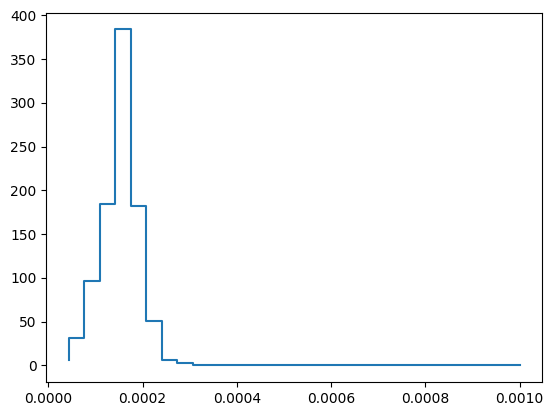

In [ ]:
cat = cat_f_rc
h = np.histogram(cat.catalog['N(CO)']/(cat.catalog['Av']*1.1e21), bins=30, range=(1e-5, 1e-3))
plt.step(h[1][1:], h[0], where='pre')


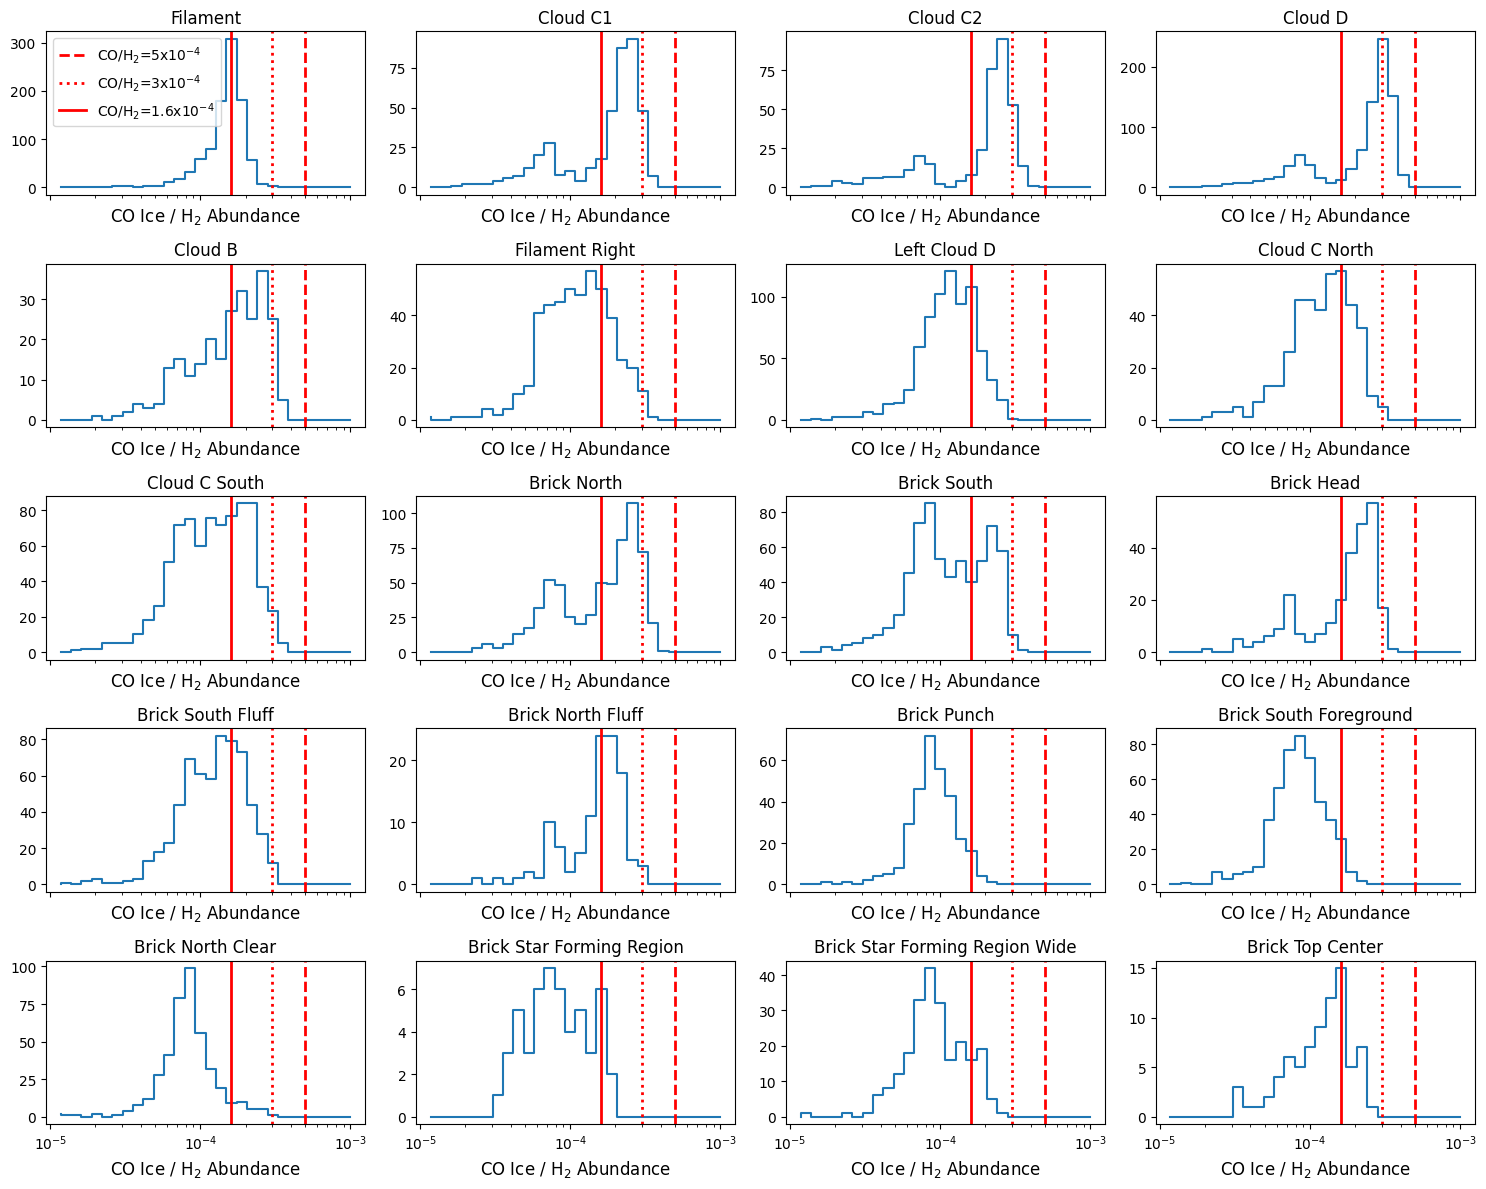

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharex=True)#, sharey=True)

catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']

for i in range(20):
    ax = axes.flatten()[i]
    cat = catalog_list[i]
    h = np.histogram(cat.catalog['N(CO)']/(cat.catalog['Av']*1.1e21), bins=np.logspace(-5, -3, 30))#, range=(1e-5, 1e-3))
    ax.step(h[1][1:], h[0], where='pre')
    
    ax.set_title(name_list[i])

    ax.axvline(5e-4, linewidth=2, color='r', linestyle='--', label='CO/H$_2$=5x10$^{-4}$')
    ax.axvline(3e-4, linewidth=2, color='r', linestyle=':', label='CO/H$_2$=3x10$^{-4}$')
    ax.axvline(1.6e-4, linewidth=2, color='r', linestyle='-', label='CO/H$_2$=1.6x10$^{-4}$')

    ax.set_xlabel('CO Ice / H$_2$ Abundance', fontsize=12)
    ax.set_xscale('log')
    #ax.set_xlim(10, 80)
    #ax.set_ylim(1e-5, 1e-3)

    if i == 0:
        ax.legend(loc='upper left')#, bbox_to_anchor=(1.05, 0.1))

plt.tight_layout()

#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund_hist.png', dpi=300, bbox_inches='tight')
#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund_hist.pdf', bbox_inches='tight')

In [ ]:
catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']

mean_NCO = []
std_NCO = []
unc_NCO = []
mean_CO_abund = []
std_CO_abund = []
unc_CO_abund = []


for i in range(20):
    #ax = axes.flatten()[i]
    cat = catalog_list[i]
    nCO = cat.catalog['N(CO)'].copy()
    av = cat.catalog['Av']
    nCO[nCO <= 0] = np.nan
    nCO[cat.color('f405n', 'f466n') > 0] = np.nan
    nCO[av < 25] = np.nan
    mean_NCO.append(np.nanmean(nCO))
    std_NCO.append(np.nanstd(nCO))
    unc_NCO.append(std_NCO[-1] / np.sqrt(len(np.array(nCO))))
    mean_CO_abund.append(np.nanmean(nCO/(cat.catalog['Av']*1.1e21)))
    std_CO_abund.append(np.nanstd(nCO/(cat.catalog['Av']*1.1e21)))
    unc_CO_abund.append(std_CO_abund[-1] / np.sqrt(len(np.array(nCO))))

from astropy.table import Table
tbl = Table()
tbl['Region'] = name_list
#tbl['Mean N(CO Ice) [cm^-2] x 1e18'] = np.round(np.array(mean_NCO) / 1e18, 2)
#tbl['Std N(CO Ice) [cm^-2] x 1e18'] = np.round(np.array(std_NCO) / 1e18, 2)
#tbl['Uncertainty N(CO Ice) [cm^-2] x 1e18'] = np.round(np.array(unc_NCO) / 1e18, 2)
tbl['Mean CO Ice / H2 Abundance x 1e-4'] = np.round(np.array(mean_CO_abund) / 1e-4, 2)
tbl['Std CO Ice / H2 Abundance x 1e-4'] = np.round(np.array(std_CO_abund) / 1e-4, 2)
tbl['Uncertainty CO Ice / H2 Abundance x 1e-4'] = np.round(np.array(unc_CO_abund) / 1e-4, 2)

tbl.write('/orange/adamginsburg/jwst/cloudc/dustridge-cd/data/CO_ice_summary.tbl', format='latex', overwrite=True)

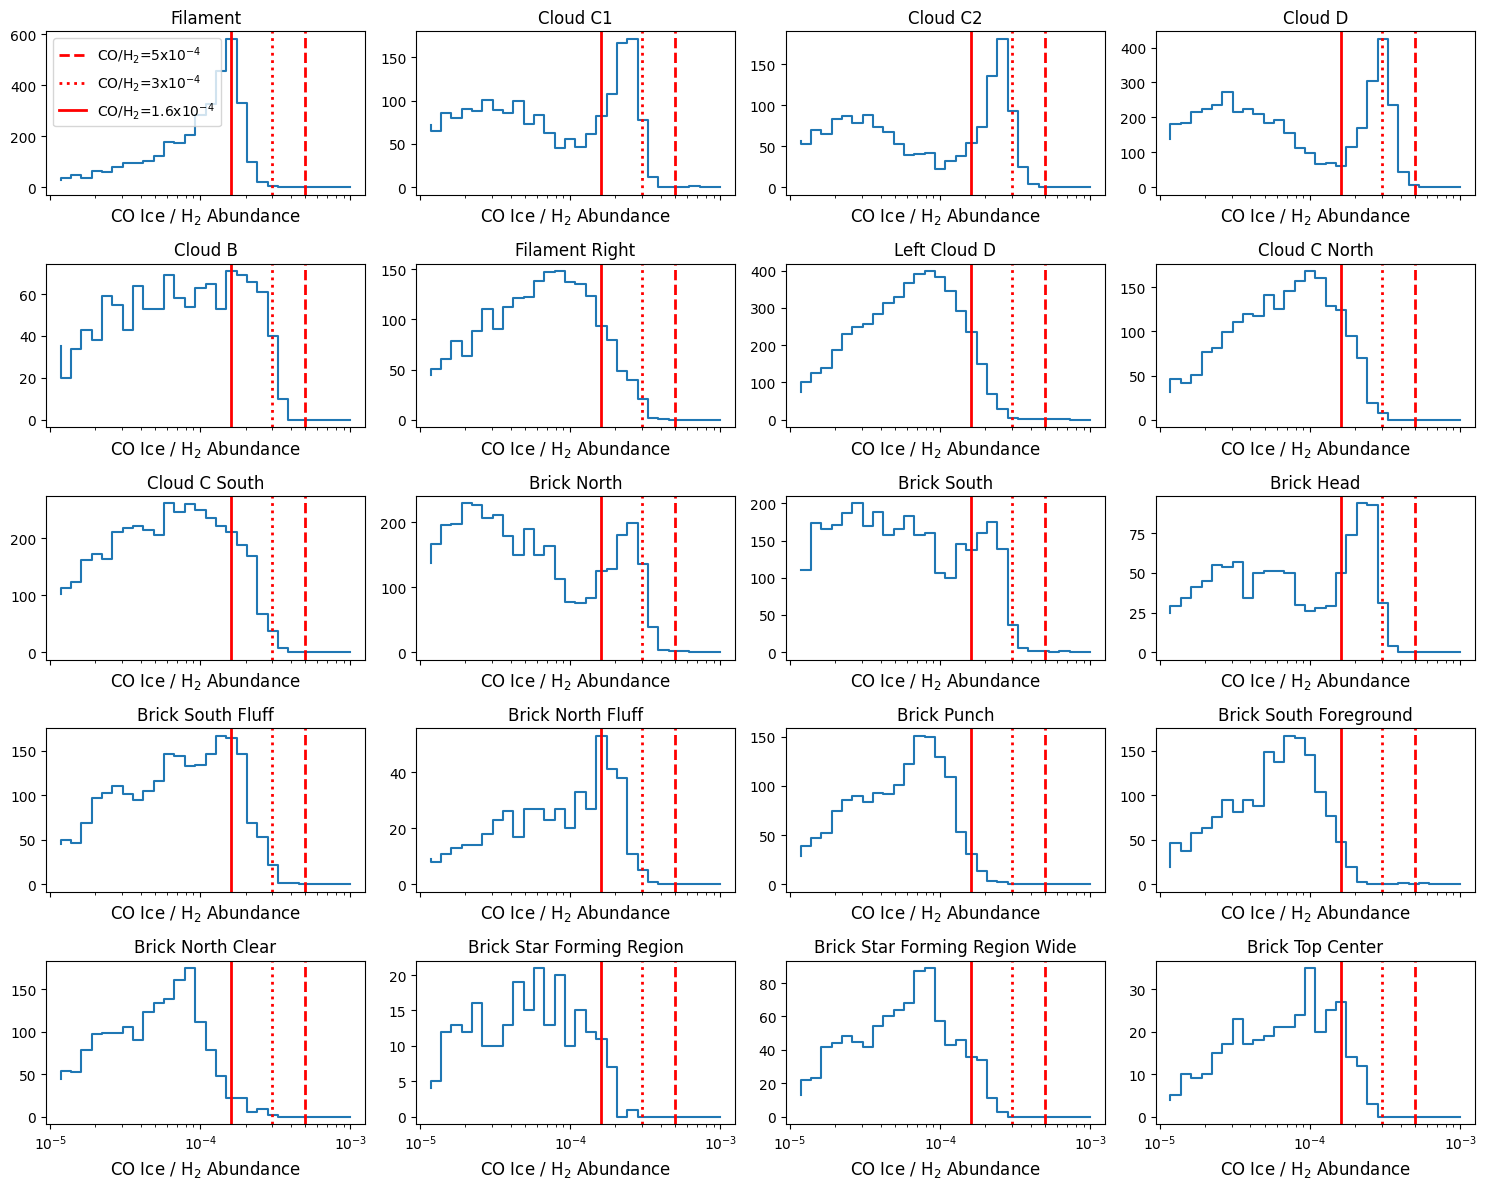

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharex=True)#, sharey=True)

catalog_list = [cat_f, cat_c1, cat_c2, cat_d, cat_b, cat_fil_r, cat_left_cd, cat_c_n, cat_c_s,
               cat_brick_north, cat_brick_south, cat_brick_head, cat_brick_sfluff, cat_brick_nfluff, 
               cat_brick_punch, cat_brick_sfore, cat_brick_nclear, cat_brick_sfr, cat_brick_sfrwide, cat_brick_topc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']

for i in range(20):
    ax = axes.flatten()[i]
    cat = catalog_list[i]
    h = np.histogram(cat.catalog['N(CO)']/(cat.catalog['Av']*1.1e21), bins=np.logspace(-5, -3, 30))#, range=(1e-5, 1e-3))
    ax.step(h[1][1:], h[0], where='pre')
    
    ax.set_title(name_list[i])

    ax.axvline(5e-4, linewidth=2, color='r', linestyle='--', label='CO/H$_2$=5x10$^{-4}$')
    ax.axvline(3e-4, linewidth=2, color='r', linestyle=':', label='CO/H$_2$=3x10$^{-4}$')
    ax.axvline(1.6e-4, linewidth=2, color='r', linestyle='-', label='CO/H$_2$=1.6x10$^{-4}$')

    ax.set_xlabel('CO Ice / H$_2$ Abundance', fontsize=12)
    ax.set_xscale('log')
    #ax.set_xlim(10, 80)
    #ax.set_ylim(1e-5, 1e-3)

    if i == 0:
        ax.legend(loc='upper left')#, bbox_to_anchor=(1.05, 0.1))

plt.tight_layout()

#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund_hist.png', dpi=300, bbox_inches='tight')
#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund_hist.pdf', bbox_inches='tight')

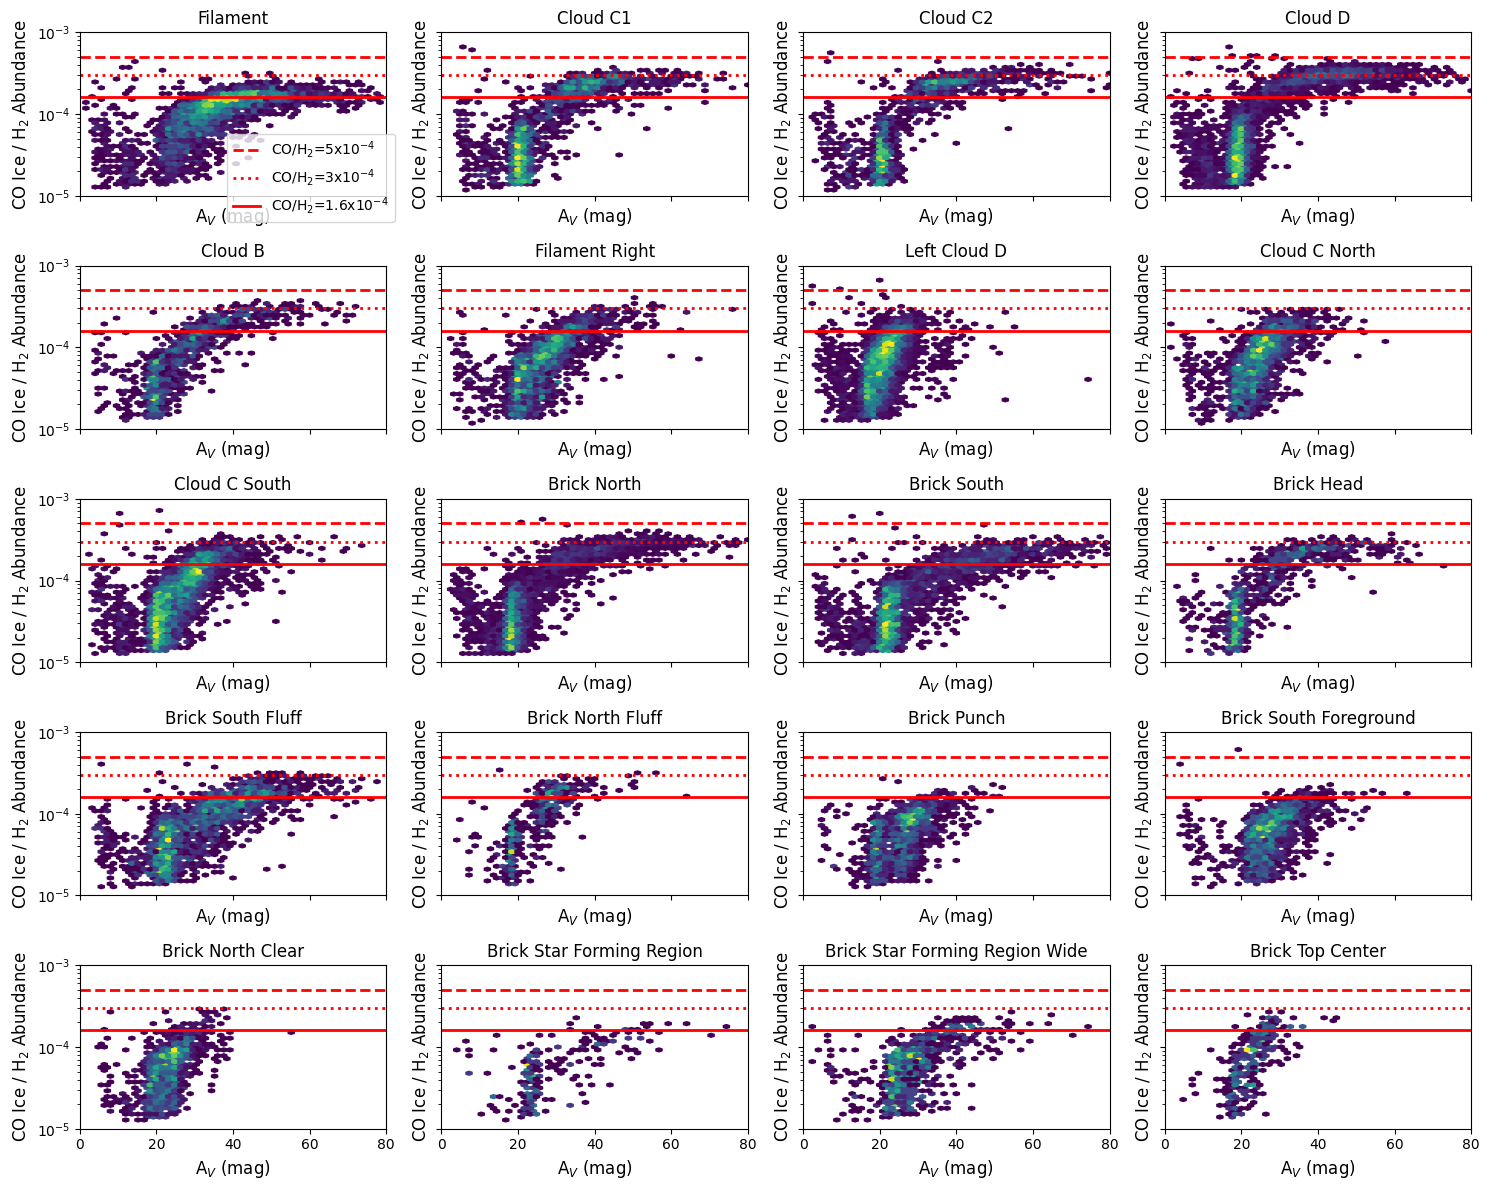

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(15, 12), sharex=True, sharey=True)

catalog_list = [cat_f, cat_c1, cat_c2, cat_d, cat_b, cat_fil_r, cat_left_cd, cat_c_n, cat_c_s,
               cat_brick_north, cat_brick_south, cat_brick_head, cat_brick_sfluff, cat_brick_nfluff, 
               cat_brick_punch, cat_brick_sfore, cat_brick_nclear, cat_brick_sfr, cat_brick_sfrwide, cat_brick_topc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']

for i in range(20):
    ax = axes.flatten()[i]
    cat = catalog_list[i]
    cat = JWSTCatalog(cat.catalog[(cat.color('f405n', 'f466n') < 0) & (cat.catalog['Av'] > 0)])
    ax.hexbin(cat.catalog['Av'], cat.catalog['N(CO)']/(cat.catalog['Av']*1.1e21), yscale='log', extent=(0, 80, np.log10(1e-5), np.log10(1e-3)), cmap='viridis', gridsize=50, mincnt=1)
    ax.set_title(name_list[i])

    ax.axhline(5e-4, linewidth=2, color='r', linestyle='--', label='CO/H$_2$=5x10$^{-4}$')
    ax.axhline(3e-4, linewidth=2, color='r', linestyle=':', label='CO/H$_2$=3x10$^{-4}$')
    ax.axhline(1.6e-4, linewidth=2, color='r', linestyle='-', label='CO/H$_2$=1.6x10$^{-4}$')

    ax.set_xlabel('A$_V$ (mag)', fontsize=12)
    ax.set_ylabel('CO Ice / H$_2$ Abundance', fontsize=12)
    ax.set_yscale('log')
    ax.set_xlim(0, 80)
    ax.set_ylim(1e-5, 1e-3)

    if i == 0:
        ax.legend(loc='lower right', bbox_to_anchor=(1.05, -0.2))#, 0.3, 1))

plt.tight_layout()

#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund.png', dpi=300, bbox_inches='tight')
#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/combined_rc_COice_abund.pdf', bbox_inches='tight')

ValueError: y contains non-positive values, so cannot be log-scaled

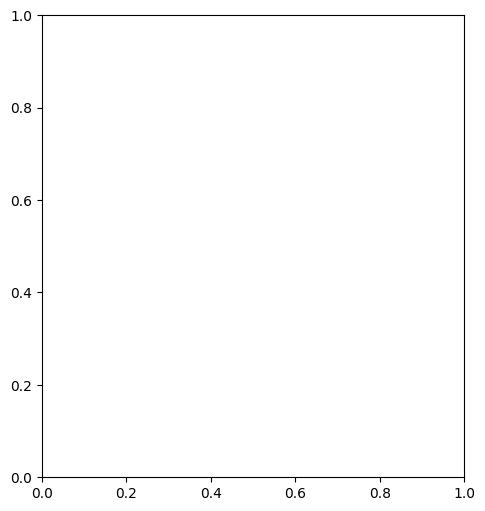

In [ ]:
fig = plt.figure(figsize=(12, 6))

ax1 = plt.subplot(121)
cat1 = cat_brick_north
ax1.hexbin(cat1.catalog['Av'], cat1.catalog['N(CO)']/(cat1.catalog['Av']*1.1e21), yscale='log', extent=(0, 80, np.log10(1e-6), np.log10(1e-3)), cmap='viridis', gridsize=50, mincnt=1)
ax1.set_title('Brick North')

ax2 = plt.subplot(122)
cat2 = cat_brick_south
ax2.hexbin(cat2.catalog['Av'], cat2.catalog['N(CO)']/(cat2.catalog['Av']*1.1e21), yscale='log', extent=(0, 80, np.log10(1e-6), np.log10(1e-3)), cmap='viridis', gridsize=50, mincnt=1)
ax2.set_title('Brick South')

for ax in [ax1, ax2]:
    ax.axhline(5e-4, linewidth=2, color='r', linestyle='--', label='CO/H$_2$=5x10$^{-4}$')
    ax.axhline(1.6e-4, linewidth=2, color='r', linestyle='-', label='CO/H$_2$=1.6x10$^{-4}$')

    ax.set_xlabel('A$_V$ (mag)', fontsize=12)
    ax.set_ylabel('CO Ice / H$_2$ Abundance', fontsize=12)
    ax.set_yscale('log')
    ax.set_xlim(0, 80)
    ax.set_ylim(1e-5, 1e-3)

    ax.axvline(17, color='k', linestyle=':', label='Av=17 mag')
    ax.axvline(25, color='k', linestyle='--', label='Av=25 mag')
    ax.legend(loc='lower right')

In [ ]:
np.nansum(cat.catalog['Av'] < 0)

np.int64(0)

In [ ]:
Av_bins = np.arange(10, 81, 10)
# average N(CO) in each bin of Av for each region
mean_NCO_per_bin = []
for i in range(len(catalogs_rc)):
    cat = catalogs_rc[i]
    mean_NCO = []
    for j in range(len(Av_bins)-1):
        bin_mask = (cat.catalog['Av'] >= Av_bins[j]) & (cat.catalog['Av'] < Av_bins[j+1])
        mean_NCO.append(np.nanmean(cat.catalog['N(CO)'][bin_mask]))
    mean_NCO_per_bin.append(mean_NCO)

/scratch/local/27808237/ipykernel_36601/1124746653.py:9: RuntimeWarning: Mean of empty slice
  mean_NCO.append(np.nanmean(cat.catalog['N(CO)'][bin_mask]))


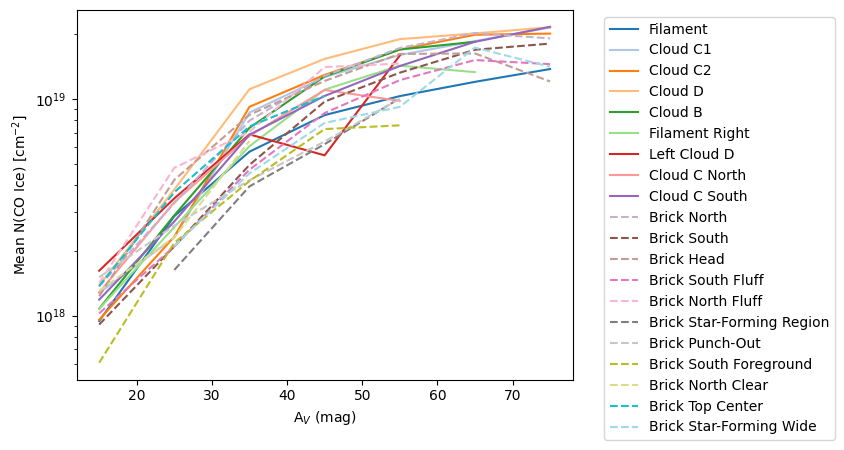

In [ ]:
#plt.plot(Av_bins[:-1]+5, np.array(mean_NCO_per_bin).T)
# plot each line with labels, change linestyle for brick vs non-brick
colors = plt.cm.tab20.colors
for i in range(len(catalogs_rc)):
    plt.plot(Av_bins[:-1]+5, mean_NCO_per_bin[i], label=labels[i], linestyle='--' if 'Brick' in labels[i] else '-', color=colors[i % len(colors)])

plt.yscale('log')
plt.xlabel('A$_V$ (mag)')
plt.ylabel('Mean N(CO Ice) [cm$^{-2}$]')
# move legend outside plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

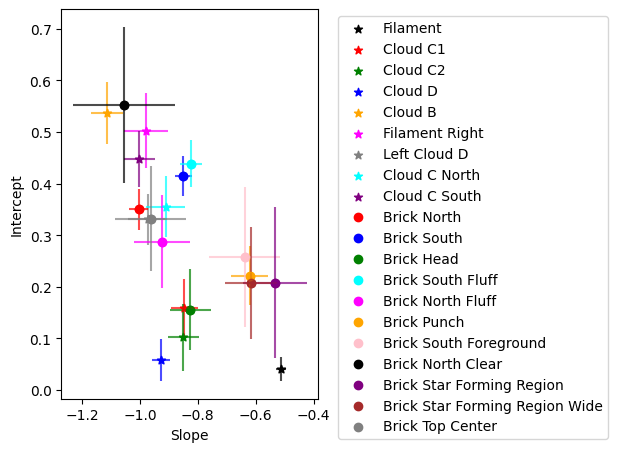

In [ ]:
catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']
color_list = ['k', 'r', 'g', 'b', 'orange', 'magenta', 'grey', 'cyan', 'purple', 'r', 'b', 'g', 'cyan', 'magenta', 'orange', 'pink', 'k', 'purple', 'brown', 'gray']
cutoffs = [0.75, 0.8, 0.8, 0.75, 0.75, 0.7, 0.6, 0.7, 0.8, 0.8, 0.9, 0.75, 0.9, 0.7, 0.75, 1, 0.8, 1, 1, 0.7]
rang = np.linspace(0.5, 2.7, 100)

ax = plt.subplot(111)

for i in range(len(catalog_list)):
    cat = catalog_list[i]
    cat = JWSTCatalog(cat.catalog[cat.color('f182m', 'f212n') > cutoffs[i]])
    #cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=name_list[i], color=color_list[i])
    #ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    slopes = []
    intercepts = []

    for j in range(1000):
        indices = np.random.choice(len(x), len(x), replace=True)
        x_boot = x[indices]
        y_boot = y[indices]
        
        fit = fitting.LinearLSQFitter()
        line_boot = fit(models.Linear1D(), x_boot, y_boot)
        slopes.append(line_boot.slope.value)
        intercepts.append(line_boot.intercept.value)
        #ax.plot(rang, line_boot(rang), color='gray', alpha=0.01)

    #ax.plot(rang, np.mean(slopes) * rang + np.mean(intercepts), color='r', label=f'y = ({np.mean(slopes):.2f}$\pm${np.std(slopes):.2f})x + ({np.median(intercepts):.2f}$\pm${np.std(intercepts):.2f})', linewidth=2, linestyle='--')
    #ax.set_xlim(0.5, 2.7)
    #ax.set_ylim(-2.3, 0.5)
    #ax.legend(loc='upper right')
    #ax.axvline(0.8)
    marker = 'o' if 'Brick' in name_list[i] else '*'

    ax.errorbar(np.mean(slopes), np.median(intercepts), xerr=np.std(slopes), yerr=np.std(intercepts), fmt=marker, color=color_list[i], alpha=0.7)
    ax.scatter(np.mean(slopes), np.median(intercepts), label=name_list[i], color=color_list[i], marker=marker)

ax.set_xlabel('Slope')
ax.set_ylabel('Intercept')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


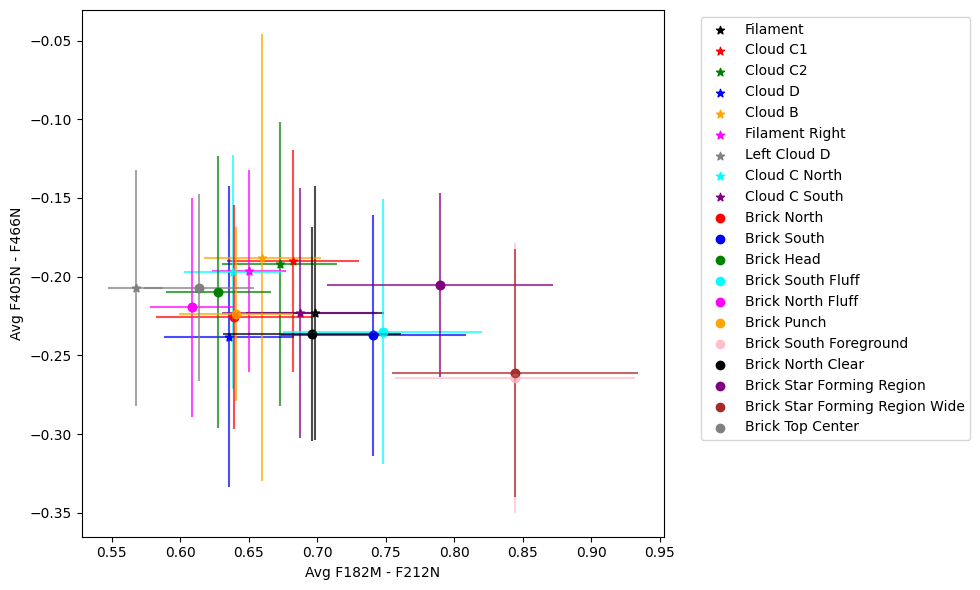

In [ ]:
catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']
color_list = ['k', 'r', 'g', 'b', 'orange', 'magenta', 'grey', 'cyan', 'purple', 'r', 'b', 'g', 'cyan', 'magenta', 'orange', 'pink', 'k', 'purple', 'brown', 'gray']
cutoffs = [0.75, 0.8, 0.8, 0.75, 0.75, 0.7, 0.6, 0.7, 0.8, 0.8, 0.9, 0.75, 0.9, 0.7, 0.75, 1, 0.8, 1, 1, 0.7]
rang = np.linspace(0.5, 2.7, 100)

fig = plt.figure(figsize=(10,6))
ax = plt.subplot(111)

for i in range(len(catalog_list)):
    cat = catalog_list[i]
    cat = JWSTCatalog(cat.catalog[cat.color('f182m', 'f212n') < cutoffs[i]])
    #cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=name_list[i], color=color_list[i])
    #ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    
    avg_x = np.nanmean(x)
    std_x = np.nanstd(x)
    avg_y = np.nanmean(y)
    std_y = np.nanstd(y)

    marker = 'o' if 'Brick' in name_list[i] else '*'

    ax.errorbar(avg_x, avg_y, xerr=std_x, yerr=std_y, fmt=marker, color=color_list[i], alpha=0.7)
    ax.scatter(avg_x, avg_y, label=name_list[i], color=color_list[i], marker=marker)

ax.set_xlabel('Avg F182M - F212N')
ax.set_ylabel('Avg F405N - F466N')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


<Axes: xlabel='[F182M] - [F212N]', ylabel='[F405N] - [F466N]'>

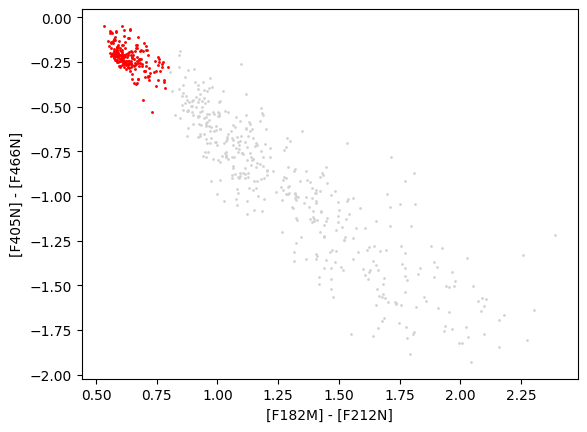

In [ ]:
cat = JWSTCatalog(cat_brick_north_rc.catalog[cat_brick_north_rc.color('f182m', 'f212n') < 0.8])
cat_brick_north_rc.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='lightgray', label='Brick North', s=1)
cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', color='r', label='Brick North', s=1)

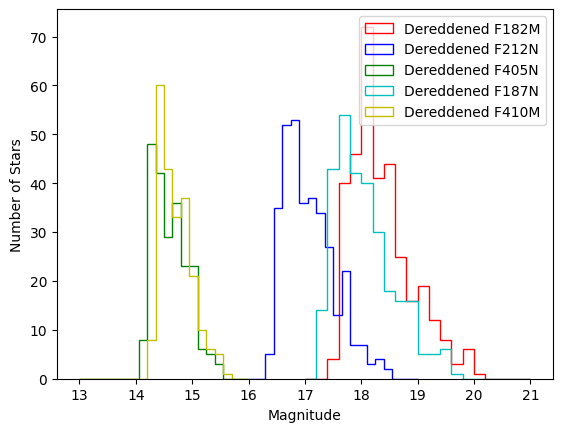

In [ ]:
def deredden_mag(cat, ext, band, Av):
    # K0 = K - (H-K - (H-K)0) / (A_H / A_K - 1)
    # (H-K)0 = intrinsic color of RC stars
    # what is the intrinsic color of RC stars in F182M-F212N
    # 
    A_band = ext(int(band[1:-1])/100*u.um)
    return cat.band(band) + A_band * Av

cat = JWSTCatalog(cat_brick_north_rc.catalog[cat_brick_north_rc.color('f182m', 'f212n') < 0.8])

dereddened_f182m = deredden_mag(cat, CT06_MWGC(), 'f182m', cat.catalog['Av'])
dereddened_f212n = deredden_mag(cat, CT06_MWGC(), 'f212n', cat.catalog['Av'])
dereddened_f405n = deredden_mag(cat, CT06_MWGC(), 'f405n', cat.catalog['Av'])
dereddened_f466n = deredden_mag(cat, CT06_MWGC(), 'f466n', cat.catalog['Av'])
dereddened_f187n = deredden_mag(cat, CT06_MWGC(), 'f187n', cat.catalog['Av'])
dereddened_f410m = deredden_mag(cat, CT06_MWGC(), 'f410m', cat.catalog['Av'])

plt.hist(dereddened_f182m, bins=20, range=(17, 21), histtype='step', color='r', label='Dereddened F182M')
plt.hist(dereddened_f212n, bins=20, range=(16, 19), histtype='step', color='b', label='Dereddened F212N')
plt.hist(dereddened_f405n, bins=20, range=(13, 16), histtype='step', color='g', label='Dereddened F405N')
plt.hist(dereddened_f187n, bins=20, range=(17, 21), histtype='step', color='c', label='Dereddened F187N')
plt.hist(dereddened_f410m, bins=20, range=(13, 16), histtype='step', color='y', label='Dereddened F410M')
#plt.hist(dereddened_f466n, bins=25, range=(15, 20), histtype='step', color='m', label='Dereddened F466N')
plt.xlabel('Magnitude')
plt.ylabel('Number of Stars')
plt.legend()

/scratch/local/28127996/ipykernel_402108/3819629213.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
/scratch/local/28127996/ipykernel_402108/3819629213.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)


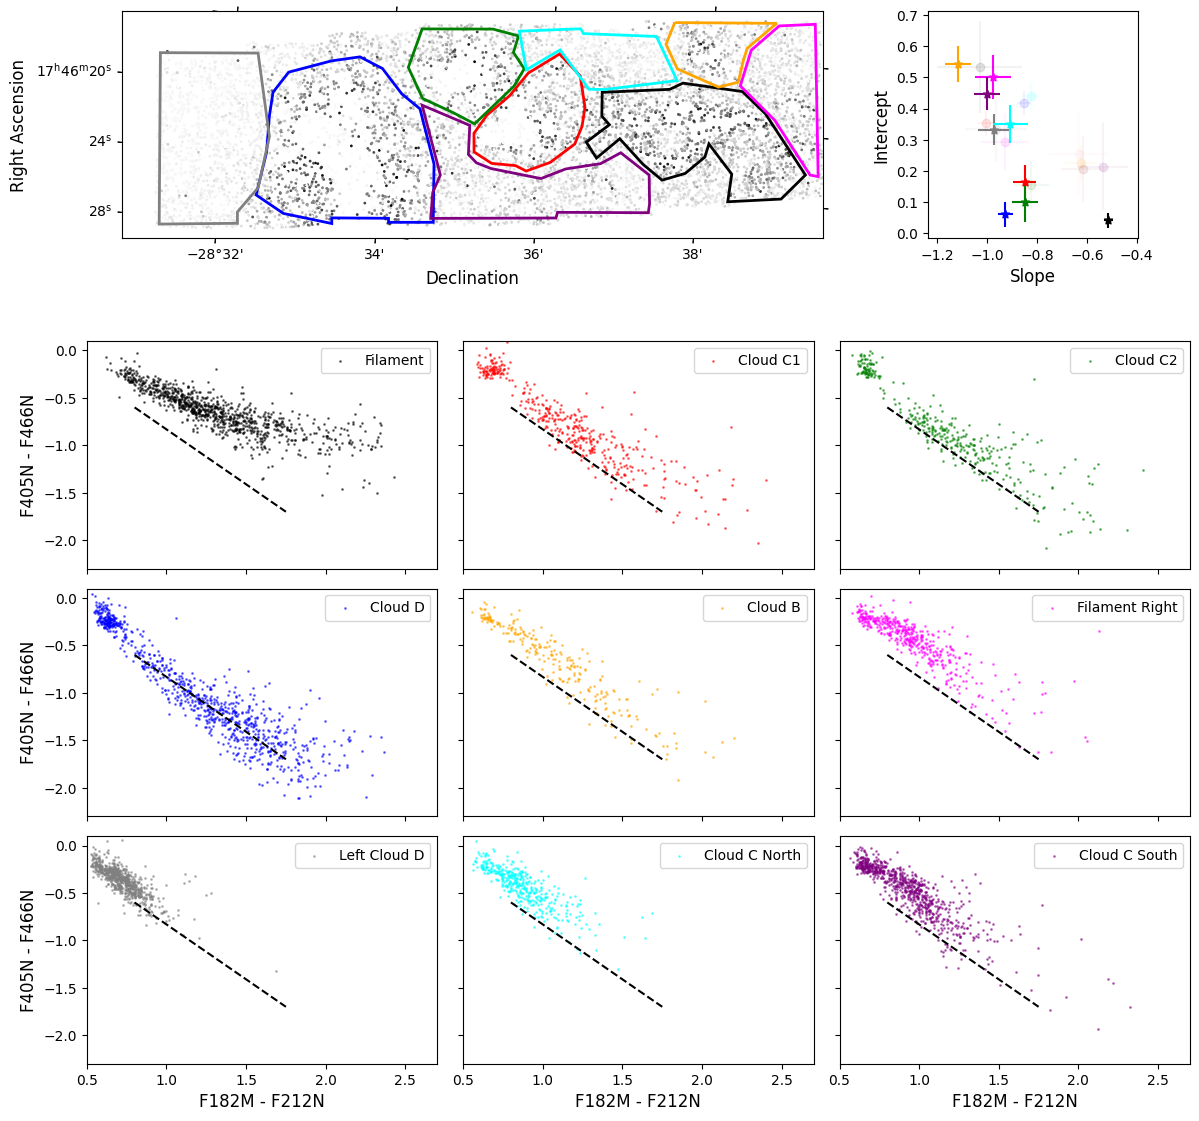

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(12,8), sharex=True, sharey=True)
catalogs_filament = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc]
labels_filament = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South']
colors_filament = ['k', 'r', 'g', 'b', 'orange', 'magenta', 'grey', 'cyan', 'purple']

for i in range(len(catalogs_filament)):
    cat = catalogs_filament[i]
    ax = axes.flatten()[i]
    cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=labels_filament[i], color=colors_filament[i])
    if i > 5:
        ax.set_xlabel('F182M - F212N', fontsize=12)
    else: 
        ax.set_xlabel('')
    if i % 3 == 0:
        ax.set_ylabel('F405N - F466N', fontsize=12)
    else: 
        ax.set_ylabel('')
    ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    ax.legend()
    ax.set_xlim(0.5, 2.7)
    ax.set_ylim(-2.3, 0.1)

plt.tight_layout()

ax = axes.flatten()[0].inset_axes([0.1, 1.2, 2, 1.5], projection=ww) #plt.subplot(411, projection=ww)
ax.imshow(nanfield)
im = ax.scatter(cat_rc.ra, cat_rc.dec, c=cat_rc.color('f182m', 'f212n'), s=1, cmap='Greys', transform=ax.get_transform('world'))
#im = cat_rc.plot_position(s=1, c=cat_rc.color('f182m', 'f212n'), cmap='Greys', transform=ax.get_transform('world'))
#cax = ax.inset_axes([1.01, 0., 0.03, 1])
#cbar = plt.colorbar(im, cax=cax, orientation='vertical')
#cbar.set_label('[F182M] - [F212N]', fontsize=10)
ax.set_xlabel('Declination', fontsize=12)
ax.set_ylabel('Right Ascension', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

reg_f[0].to_pixel(ww).plot(ax=ax, edgecolor='k', facecolor='none', lw=2)
reg_c1[0].to_pixel(ww).plot(ax=ax, edgecolor='r', facecolor='none', lw=2)
reg_c2[0].to_pixel(ww).plot(ax=ax, edgecolor='g', facecolor='none', lw=2)
reg_d[0].to_pixel(ww).plot(ax=ax, edgecolor='b', facecolor='none', lw=2)
reg_b[0].to_pixel(ww).plot(ax=ax, edgecolor='orange', facecolor='none', lw=2)
reg_fil_r[0].to_pixel(ww).plot(ax=ax, edgecolor='magenta', facecolor='none', lw=2)
reg_left_cd[0].to_pixel(ww).plot(ax=ax, edgecolor='grey', facecolor='none', lw=2)
reg_c_s[0].to_pixel(ww).plot(ax=ax, edgecolor='purple', facecolor='none', lw=2)
reg_c_n[0].to_pixel(ww).plot(ax=ax, edgecolor='cyan', facecolor='none', lw=2)

ax2 = ax.inset_axes([1.15, 0, 0.3, 1])

catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']
color_list = ['k', 'r', 'g', 'b', 'orange', 'magenta', 'grey', 'cyan', 'purple', 'r', 'b', 'g', 'cyan', 'magenta', 'orange', 'pink', 'k', 'purple', 'brown', 'gray']
cutoffs = [0.75, 0.8, 0.8, 0.75, 0.75, 0.7, 0.6, 0.7, 0.8, 0.8, 0.9, 0.75, 0.9, 0.7, 0.75, 1, 0.8, 1, 1, 0.7]
rang = np.linspace(0.5, 2.7, 100)

for i in range(len(catalog_list)):
    cat = catalog_list[i]
    cat = JWSTCatalog(cat.catalog[cat.color('f182m', 'f212n') > cutoffs[i]])
    #cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=name_list[i], color=color_list[i])
    #ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    slopes = []
    intercepts = []

    for j in range(1000):
        indices = np.random.choice(len(x), len(x), replace=True)
        x_boot = x[indices]
        y_boot = y[indices]
        
        fit = fitting.LinearLSQFitter()
        line_boot = fit(models.Linear1D(), x_boot, y_boot)
        slopes.append(line_boot.slope.value)
        intercepts.append(line_boot.intercept.value)
        #ax.plot(rang, line_boot(rang), color='gray', alpha=0.01)

    #ax.plot(rang, np.mean(slopes) * rang + np.mean(intercepts), color='r', label=f'y = ({np.mean(slopes):.2f}$\pm${np.std(slopes):.2f})x + ({np.median(intercepts):.2f}$\pm${np.std(intercepts):.2f})', linewidth=2, linestyle='--')
    #ax.set_xlim(0.5, 2.7)
    #ax.set_ylim(-2.3, 0.5)
    #ax.legend(loc='upper right')
    #ax.axvline(0.8)
    marker = 'o' if 'Brick' in name_list[i] else '*'
    alpha = 0.05 if 'Brick' in name_list[i] else 1

    ax2.errorbar(np.mean(slopes), np.median(intercepts), xerr=np.std(slopes), yerr=np.std(intercepts), fmt=marker, color=color_list[i], alpha=alpha)
    ax2.scatter(np.mean(slopes), np.median(intercepts), label=name_list[i], color=color_list[i], marker=marker, alpha=alpha)

ax2.set_xlabel('Slope', fontsize=12)
ax2.set_ylabel('Intercept', fontsize=12)

#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/dustridge_rc_CCDs.png', dpi=300, bbox_inches='tight')
#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/dustridge_rc_CCDs.pdf', bbox_inches='tight')

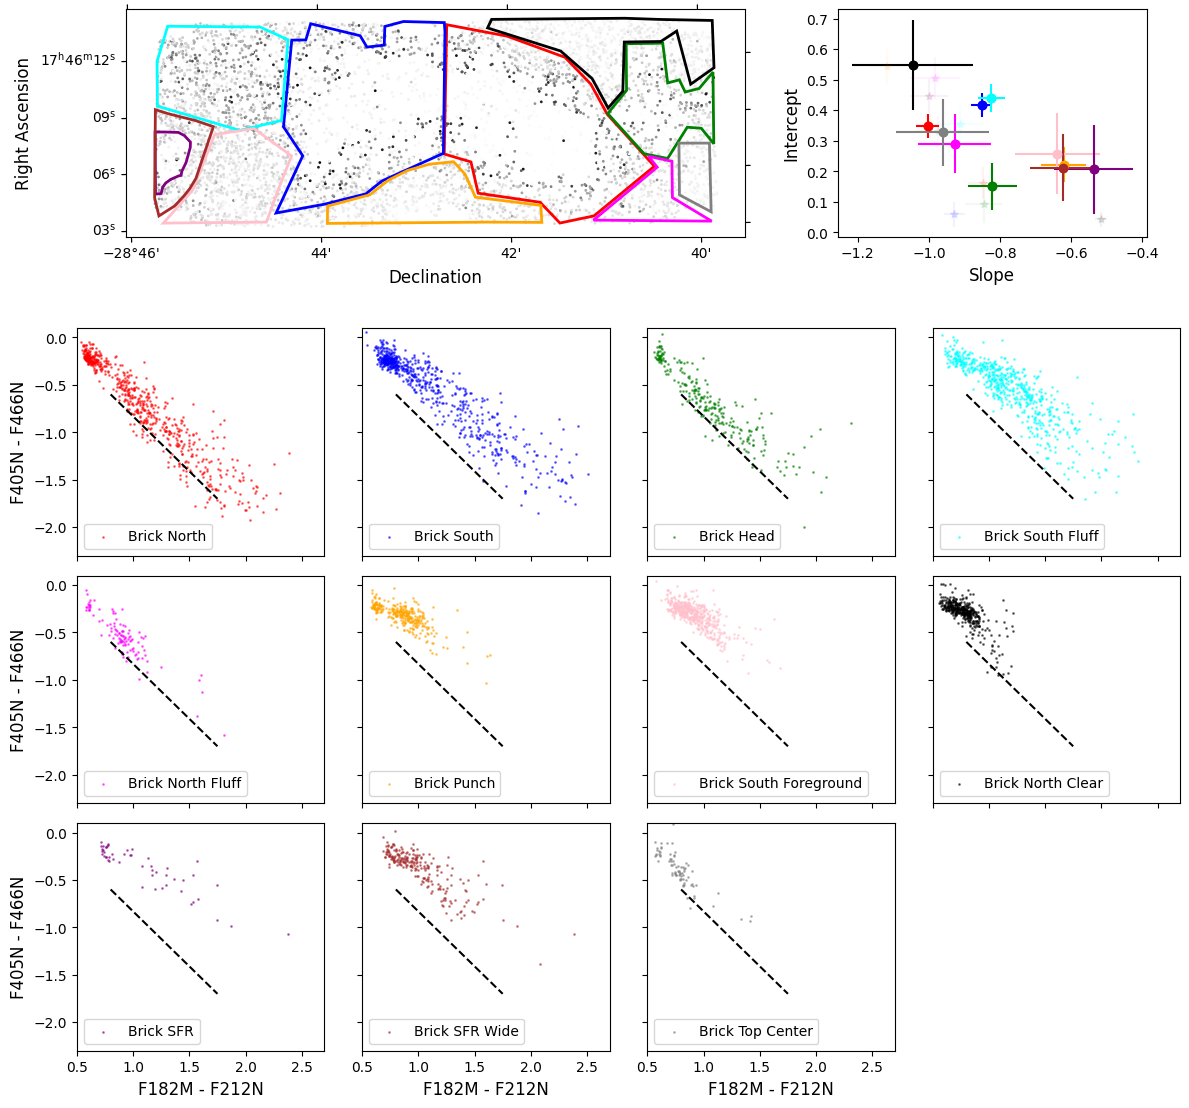

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(12,8), sharex=True, sharey=True)
catalogs_brick = [cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
                  cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
labels_brick = ['Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 
                'Brick South Foreground', 'Brick North Clear', 'Brick SFR', 'Brick SFR Wide', 'Brick Top Center']
colors_brick = ['r', 'b', 'g', 'cyan', 'magenta', 'orange', 'pink', 'k', 'purple', 'brown', 'gray']

for i in range(len(catalogs_brick)):
    ax = axes.flatten()[i]
    cat = catalogs_brick[i]
    cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=labels_brick[i], color=colors_brick[i])
    if i > 7:
        ax.set_xlabel('F182M - F212N', fontsize=12)
    else: 
        ax.set_xlabel('')
    if i % 4 == 0:
        ax.set_ylabel('F405N - F466N', fontsize=12)
    else: 
        ax.set_ylabel('')
    ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    ax.legend(loc='lower left')
    ax.set_xlim(0.5, 2.7)
    ax.set_ylim(-2.3, 0.1)

axes.flatten()[-1].axis('off')

plt.tight_layout()

ax = axes.flatten()[0].inset_axes([0.2, 1.4, 2.5, 1], projection=ww_brick)
plt.imshow(nanfield_brick)
cat_brick_rc.plot_position(ax=ax, transform=ax.get_transform('world'), s=1, cmap='Greys', c=cat_brick_rc.color('f182m', 'f212n'))
ax.set_xlabel('Declination', fontsize=12)
ax.set_ylabel('Right Ascension', fontsize=12)

reg_brick_north[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='red')
reg_brick_south[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='blue')
reg_brick_head[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='green')
reg_brick_sfluff[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='cyan')
reg_brick_nfluff[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='magenta')
reg_brick_sfr[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='purple')
reg_brick_punch[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='orange')
reg_brick_sfore[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='pink')
reg_brick_nclear[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='k')
reg_brick_topc[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='gray')
reg_brick_sfrwide[0].to_pixel(ww_brick).plot(ax=ax, facecolor='none', edgecolor='brown')

ax2 = ax.inset_axes([1.15, 0, 0.5, 1])

catalog_list = [cat_f_rc, cat_c1_rc, cat_c2_rc, cat_d_rc, cat_b_rc, cat_fil_r_rc, cat_left_cd_rc, cat_c_n_rc, cat_c_s_rc,
               cat_brick_north_rc, cat_brick_south_rc, cat_brick_head_rc, cat_brick_sfluff_rc, cat_brick_nfluff_rc, 
               cat_brick_punch_rc, cat_brick_sfore_rc, cat_brick_nclear_rc, cat_brick_sfr_rc, cat_brick_sfrwide_rc, cat_brick_topc_rc]
name_list = ['Filament', 'Cloud C1', 'Cloud C2', 'Cloud D', 'Cloud B', 'Filament Right', 'Left Cloud D', 'Cloud C North', 'Cloud C South',
             'Brick North', 'Brick South', 'Brick Head', 'Brick South Fluff', 'Brick North Fluff', 'Brick Punch', 'Brick South Foreground', 
             'Brick North Clear', 'Brick Star Forming Region', 'Brick Star Forming Region Wide', 'Brick Top Center']
color_list = ['k', 'r', 'g', 'b', 'orange', 'magenta', 'grey', 'cyan', 'purple', 'r', 'b', 'g', 'cyan', 'magenta', 'orange', 'pink', 'k', 'purple', 'brown', 'gray']
cutoffs = [0.75, 0.8, 0.8, 0.75, 0.75, 0.7, 0.6, 0.7, 0.8, 0.8, 0.9, 0.75, 0.9, 0.7, 0.75, 1, 0.8, 1, 1, 0.7]
rang = np.linspace(0.5, 2.7, 100)

for i in range(len(catalog_list)):
    cat = catalog_list[i]
    cat = JWSTCatalog(cat.catalog[cat.color('f182m', 'f212n') > cutoffs[i]])
    #cat.plot_CCD('f182m', 'f212n', 'f405n', 'f466n', ax=ax, s=1, alpha=0.5, label=name_list[i], color=color_list[i])
    #ax.plot([0.8, 1.75], [-0.6, -1.7], color='k', linestyle='dashed')
    x = cat.color('f182m', 'f212n')
    y = cat.color('f405n', 'f466n')
    slopes = []
    intercepts = []

    for j in range(1000):
        indices = np.random.choice(len(x), len(x), replace=True)
        x_boot = x[indices]
        y_boot = y[indices]
        
        fit = fitting.LinearLSQFitter()
        line_boot = fit(models.Linear1D(), x_boot, y_boot)
        slopes.append(line_boot.slope.value)
        intercepts.append(line_boot.intercept.value)
        #ax.plot(rang, line_boot(rang), color='gray', alpha=0.01)

    #ax.plot(rang, np.mean(slopes) * rang + np.mean(intercepts), color='r', label=f'y = ({np.mean(slopes):.2f}$\pm${np.std(slopes):.2f})x + ({np.median(intercepts):.2f}$\pm${np.std(intercepts):.2f})', linewidth=2, linestyle='--')
    #ax.set_xlim(0.5, 2.7)
    #ax.set_ylim(-2.3, 0.5)
    #ax.legend(loc='upper right')
    #ax.axvline(0.8)
    marker = 'o' if 'Brick' in name_list[i] else '*'
    alpha = 1 if 'Brick' in name_list[i] else 0.05

    ax2.errorbar(np.mean(slopes), np.median(intercepts), xerr=np.std(slopes), yerr=np.std(intercepts), fmt=marker, color=color_list[i], alpha=alpha)
    ax2.scatter(np.mean(slopes), np.median(intercepts), label=name_list[i], color=color_list[i], marker=marker, alpha=alpha)

ax2.set_xlabel('Slope', fontsize=12)
ax2.set_ylabel('Intercept', fontsize=12)

#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/brick_rc_CCDs.png', dpi=300, bbox_inches='tight')
#plt.savefig('/orange/adamginsburg/jwst/cloudc/figures/brick_rc_CCDs.pdf', bbox_inches='tight')

# Grid Figure